# Adapted Dynamic Model Fusion for Credit Rating

Notebook nay ap dung **Dynamic Model Fusion / Dynamic Classifier Selection (DMF/DCS)** tu paper cho bai toan xep hang tin dung doanh nghiep.

Anh xa phuong phap:
- Paper: `CNN` hoc dac trung cuc bo, `GCNN` hoc quan he do thi tren MRI.
- Bai toan nay: `TLSTM` hoc chuoi tai chinh/thoi gian, `GAT` hoc quan he do thi doanh nghiep.
- Phan duoc tai su dung truc tiep la **decision-level DCS**: neu hai mo hinh dong thuan thi lay nhan chung; neu bat dong thi chon mo hinh co diem tin cay dong cao hon dua tren validation competence va confidence cua mau test.

Luu y viet luan van: day la **DMF/DCS adapted to TLSTM-GAT credit rating**, khong phai tai hien nguyen kien truc MRI CNN-GCNN cua paper.

Input bat buoc:
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_tlstm/tlstm_val_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_tlstm/tlstm_test_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_tlstm/gat_val_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_tlstm/gat_test_predictions.csv`


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc as sklearn_auc,
    cohen_kappa_score, confusion_matrix, classification_report,
)
from sklearn.preprocessing import label_binarize

SEED = 42
np.random.seed(SEED)


def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start


def first_dir_with(filename: str, candidates: list[Path]) -> Path:
    for candidate in candidates:
        if (candidate / filename).exists():
            return candidate
    return candidates[0]


PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
KAGGLE_DMF_ROOT = Path('/kaggle/input/datasets/tailength/dmf-artifacts')

KAGGLE_TLSTM_CANDIDATES = [
    KAGGLE_DMF_ROOT / 'dmf_gat_tlstm',
    KAGGLE_DMF_ROOT / 'dmf_gat_lstm',
]
KAGGLE_GAT_CANDIDATES = [
    KAGGLE_DMF_ROOT / 'dmf_gat_tlstm',
    KAGGLE_DMF_ROOT / 'dmf_gat_lstm',
]
LOCAL_TLSTM_CANDIDATES = [
    PROJECT_ROOT / 'artifacts' / 'TLSTM' / 'dmf_gat_lstm',
    PROJECT_ROOT / 'credit_rating_artifacts' / 'dmf_gat_tlstm',
]
LOCAL_GAT_CANDIDATES = [
    PROJECT_ROOT / 'artifacts' / 'GAT' / 'dmf_gat_lstm',
    PROJECT_ROOT / 'credit_rating_artifacts' / 'dmf_gat_tlstm',
    PROJECT_ROOT / 'credit_rating_artifacts' / 'dmf_gat_lstm',
]

TLSTM_INPUT_ARTIFACT_DIR = first_dir_with(
    'tlstm_val_predictions.csv',
    KAGGLE_TLSTM_CANDIDATES if IN_KAGGLE else LOCAL_TLSTM_CANDIDATES,
)
GAT_INPUT_ARTIFACT_DIR = first_dir_with(
    'gat_val_predictions.csv',
    KAGGLE_GAT_CANDIDATES if IN_KAGGLE else LOCAL_GAT_CANDIDATES,
)
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_tlstm'
try:
    DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
except PermissionError:
    if IN_KAGGLE:
        raise
    DMF_ARTIFACT_DIR = PROJECT_ROOT / 'tmp' / 'dmf_gat_tlstm'
    DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    print('Canh bao: khong ghi duoc credit_rating_artifacts, dung thu muc tam cho local run.')

print('Project root:', PROJECT_ROOT)
print('TLSTM input artifact dir:', TLSTM_INPUT_ARTIFACT_DIR)
print('GAT input artifact dir:', GAT_INPUT_ARTIFACT_DIR)
print('DMF output artifact dir:', DMF_ARTIFACT_DIR)


Project root: /kaggle/working
TLSTM input artifact dir: /kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm
GAT input artifact dir: /kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm
DMF output artifact dir: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm


In [2]:
TLSTM_VAL_PATH = TLSTM_INPUT_ARTIFACT_DIR / 'tlstm_val_predictions.csv'
TLSTM_TEST_PATH = TLSTM_INPUT_ARTIFACT_DIR / 'tlstm_test_predictions.csv'
GAT_VAL_PATH = GAT_INPUT_ARTIFACT_DIR / 'gat_val_predictions.csv'
GAT_TEST_PATH = GAT_INPUT_ARTIFACT_DIR / 'gat_test_predictions.csv'
LABEL_MAP_PATH = TLSTM_INPUT_ARTIFACT_DIR / 'label_mapping.csv'
if not LABEL_MAP_PATH.exists():
    LABEL_MAP_PATH = GAT_INPUT_ARTIFACT_DIR / 'label_mapping.csv'

required_paths = [TLSTM_VAL_PATH, TLSTM_TEST_PATH, GAT_VAL_PATH, GAT_TEST_PATH, LABEL_MAP_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Thieu DMF input artifact. Hay chay notebook TLSTM va GAT truoc: ' + '; '.join(missing))

tlstm_val_raw = pd.read_csv(TLSTM_VAL_PATH)
tlstm_test_raw = pd.read_csv(TLSTM_TEST_PATH)
gat_val_raw = pd.read_csv(GAT_VAL_PATH)
gat_test_raw = pd.read_csv(GAT_TEST_PATH)
label_map = pd.read_csv(LABEL_MAP_PATH)

print('TLSTM val/test:', tlstm_val_raw.shape, tlstm_test_raw.shape)
print('GAT   val/test:', gat_val_raw.shape, gat_test_raw.shape)
display(label_map)


TLSTM val/test: (862, 20) (1723, 20)
GAT   val/test: (862, 17) (1723, 17)


,label_id,label_name
0,0,0
1,1,1
2,2,2


In [3]:
def prob_columns(frame):
    cols = [c for c in frame.columns if c.startswith('prob_')]
    return sorted(cols, key=lambda x: int(x.split('_')[1]))


def validate_prediction_frame(frame, model_key, split_name):
    probs = prob_columns(frame)
    if not probs:
        raise ValueError(f'{model_key} {split_name} prediction file has no prob_* columns')
    required = {'row_id', 'true_label', 'pred_label', *probs}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{model_key} {split_name} prediction file missing columns: {sorted(missing)}')
    duplicated = frame.loc[frame['row_id'].duplicated(), 'row_id'].head().tolist()
    if duplicated:
        raise ValueError(f'{model_key} {split_name} has duplicate row_id values: {duplicated}')
    return probs


def standardize_predictions(frame, model_key, split_name):
    frame = frame.copy()
    probs = validate_prediction_frame(frame, model_key, split_name)
    keep_meta = [c for c in ['row_id', 'split', 'ticker', 'company_name', 'rating_date', 'true_label', 'true_label_name'] if c in frame.columns]
    out = frame[keep_meta].copy()
    out[f'{model_key}_pred_label'] = frame['pred_label'].astype(int)
    out[f'{model_key}_confidence'] = frame['confidence'].astype(float) if 'confidence' in frame.columns else frame[probs].max(axis=1).astype(float)
    for c in probs:
        out[f'{model_key}_{c}'] = frame[c].astype(float)
    return out, probs


def align_pair(tlstm_frame, gat_frame, split_name):
    tlstm, tlstm_probs = standardize_predictions(tlstm_frame, 'tlstm', split_name)
    gat, gat_probs = standardize_predictions(gat_frame, 'gat', split_name)
    if tlstm_probs != gat_probs:
        raise ValueError(f'Probability columns mismatch on {split_name}: tlstm={tlstm_probs}, gat={gat_probs}')

    tlstm['_row_id_key'] = tlstm['row_id'].astype(str)
    gat['_row_id_key'] = gat['row_id'].astype(str)
    merged = tlstm.merge(gat, on='_row_id_key', suffixes=('_tlstm_meta', '_gat_meta'), how='inner')
    merge_mode = 'row_id'

    if len(merged) != len(tlstm) or len(merged) != len(gat):
        metadata_keys = [c for c in ['split', 'ticker', 'rating_date', 'true_label'] if c in tlstm.columns and c in gat.columns]
        if len(metadata_keys) < 4:
            raise ValueError(
                f'Row_id mismatch on {split_name}: merged={len(merged)}, tlstm={len(tlstm)}, gat={len(gat)}. '
                'Khong du metadata de fallback merge an toan.'
            )
        if tlstm.duplicated(metadata_keys).any() or gat.duplicated(metadata_keys).any():
            raise ValueError(
                f'Row_id mismatch on {split_name} va metadata key bi trung: {metadata_keys}. '
                'Can export lai artifact voi row_id thong nhat.'
            )
        merged = tlstm.merge(gat, on=metadata_keys, suffixes=('_tlstm_meta', '_gat_meta'), how='inner')
        merge_mode = 'metadata'
        if len(merged) != len(tlstm) or len(merged) != len(gat):
            raise ValueError(
                f'Metadata fallback mismatch on {split_name}: merged={len(merged)}, tlstm={len(tlstm)}, gat={len(gat)}. '
                'Kiem tra hai notebook co dung cung split va row_id khong.'
            )

    tlstm_true_col = 'true_label_tlstm_meta' if 'true_label_tlstm_meta' in merged.columns else 'true_label'
    gat_true_col = 'true_label_gat_meta' if 'true_label_gat_meta' in merged.columns else 'true_label'
    if not (merged[tlstm_true_col].astype(int).values == merged[gat_true_col].astype(int).values).all():
        row_col = 'row_id_tlstm_meta' if 'row_id_tlstm_meta' in merged.columns else 'row_id'
        bad = merged.loc[merged[tlstm_true_col].astype(int) != merged[gat_true_col].astype(int), row_col].head().tolist()
        raise ValueError(f'True label mismatch on {split_name}; examples: {bad}')

    # Normalize metadata column names after the safety checks.
    if 'row_id_tlstm_meta' in merged.columns:
        merged['tlstm_row_id'] = merged['row_id_tlstm_meta']
        merged['gat_row_id'] = merged['row_id_gat_meta']
        merged['row_id'] = merged['tlstm_row_id']
    merged['true_label'] = merged[tlstm_true_col].astype(int)
    tlstm_name_col = 'true_label_name_tlstm_meta' if 'true_label_name_tlstm_meta' in merged.columns else 'true_label_name'
    if tlstm_name_col in merged.columns:
        merged['true_label_name'] = merged[tlstm_name_col]
    for col in ['split', 'ticker', 'company_name', 'rating_date']:
        a = f'{col}_tlstm_meta'
        b = f'{col}_gat_meta'
        if a in merged.columns:
            merged[col] = merged[a]
        elif b in merged.columns:
            merged[col] = merged[b]
    print(f'{split_name} merge mode:', merge_mode)
    return merged, tlstm_probs


val_df, val_prob_cols = align_pair(tlstm_val_raw, gat_val_raw, 'val')
test_df, test_prob_cols = align_pair(tlstm_test_raw, gat_test_raw, 'test')
if val_prob_cols != test_prob_cols:
    raise ValueError(f'Probability columns mismatch between val and test: val={val_prob_cols}, test={test_prob_cols}')

n_classes = len(val_prob_cols)
class_ids = list(range(n_classes))
if not {'label_id', 'label_name'}.issubset(label_map.columns):
    raise ValueError("label_mapping.csv must contain columns: 'label_id', 'label_name'")
label_ids = sorted(label_map['label_id'].astype(int).tolist())
if label_ids != class_ids:
    raise ValueError(f'label_mapping.csv label_id mismatch: expected {class_ids}, got {label_ids}')
id_to_name = {int(r.label_id): str(r.label_name) for r in label_map.itertuples(index=False)}
class_names = [id_to_name.get(i, str(i)) for i in class_ids]

print('Aligned val/test:', val_df.shape, test_df.shape, '| n_classes:', n_classes)
print('Agreement on test:', float((test_df['tlstm_pred_label'] == test_df['gat_pred_label']).mean()))
display(test_df[['row_id', 'true_label', 'tlstm_pred_label', 'gat_pred_label']].head())


val merge mode: metadata
test merge mode: metadata
Aligned val/test: (862, 27) (1723, 27) | n_classes: 3
Agreement on test: 0.9576320371445154


,row_id,true_label,tlstm_pred_label,gat_pred_label
0,6931,1,1,1
1,7706,2,2,2
2,7217,2,2,2
3,7704,2,2,2
4,7278,2,2,2


In [ ]:
def model_prob_matrix(frame, model_key):
    cols = [f'{model_key}_prob_{i}' for i in class_ids]
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        raise ValueError(f'Missing probability columns for {model_key}: {missing}')
    probs = frame[cols].to_numpy(dtype=float)
    probs = np.clip(probs, 1e-9, 1.0)
    return probs / probs.sum(axis=1, keepdims=True)


def compute_auc_roc_ovr(y_true, proba, classes=None):
    y_true = np.asarray(y_true, dtype=int)
    proba = np.asarray(proba, dtype=float)
    if classes is None:
        classes = class_ids
    classes = [int(c) for c in classes]
    if proba.ndim != 2 or len(y_true) != len(proba) or len(classes) != proba.shape[1]:
        return float('nan')

    present_classes = [c for c in classes if np.any(y_true == c)]
    if len(present_classes) < 2:
        return float('nan')

    class_to_col = {c: i for i, c in enumerate(classes)}
    auc_values = []
    for class_id in present_classes:
        y_binary = (y_true == class_id).astype(int)
        if y_binary.min() == y_binary.max():
            continue
        try:
            auc_values.append(float(roc_auc_score(y_binary, proba[:, class_to_col[class_id]])))
        except Exception:
            continue
    return float(np.mean(auc_values)) if auc_values else float('nan')


def compute_metrics(y_true, y_pred, proba=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    out = {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision_Weighted': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Recall_Weighted': float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Macro_F1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'QWK': float(cohen_kappa_score(y_true, y_pred, weights='quadratic')),
        'Ordinal_MAE': float(np.mean(np.abs(y_true - y_pred))),
    }
    auc_roc = compute_auc_roc_ovr(y_true, proba) if proba is not None else float('nan')
    out['AUC_ROC_OVR_Macro'] = auc_roc
    out['AUC'] = auc_roc  # Backward-compatible alias for older metric exports.
    return out


def prediction_alignment_report(frame, model_key, split_name):
    exported_pred = frame[f'{model_key}_pred_label'].to_numpy(dtype=int)
    prob_pred = model_prob_matrix(frame, model_key).argmax(axis=1)
    mismatch = exported_pred != prob_pred
    return {
        'split': split_name,
        'model': model_key,
        'rows': int(len(frame)),
        'pred_label_argmax_mismatches': int(mismatch.sum()),
        'mismatch_rate': float(mismatch.mean()) if len(frame) else 0.0,
    }


val_tlstm_probs = model_prob_matrix(val_df, 'tlstm')
val_gat_probs = model_prob_matrix(val_df, 'gat')
test_tlstm_probs = model_prob_matrix(test_df, 'tlstm')
test_gat_probs = model_prob_matrix(test_df, 'gat')
y_val = val_df['true_label'].to_numpy(dtype=int)
y_test = test_df['true_label'].to_numpy(dtype=int)

# Algorithm 2 defines o_j as the classifier's predicted class label. Use the exported
# pred_label from each base-model artifact instead of recomputing it from probabilities.
val_tlstm_pred = val_df['tlstm_pred_label'].to_numpy(dtype=int)
val_gat_pred = val_df['gat_pred_label'].to_numpy(dtype=int)
test_tlstm_pred = test_df['tlstm_pred_label'].to_numpy(dtype=int)
test_gat_pred = test_df['gat_pred_label'].to_numpy(dtype=int)

prediction_alignment = pd.DataFrame([
    prediction_alignment_report(val_df, 'tlstm', 'val'),
    prediction_alignment_report(val_df, 'gat', 'val'),
    prediction_alignment_report(test_df, 'tlstm', 'test'),
    prediction_alignment_report(test_df, 'gat', 'test'),
])
display(prediction_alignment)

validation_accuracy_weights = {
    'tlstm': float(accuracy_score(y_val, val_tlstm_pred)),
    'gat': float(accuracy_score(y_val, val_gat_pred)),
}
constant_weights = {'tlstm': 1.0, 'gat': 1.0}

# Paper experiments state that a constant weighting factor was assigned to each model.
# Switch to 'validation_accuracy' only for ablation, not for the faithful paper setting.
DCS_MODEL_WEIGHT_MODE = 'constant'  # options: 'constant', 'validation_accuracy'
if DCS_MODEL_WEIGHT_MODE == 'constant':
    dcs_model_weights = constant_weights
elif DCS_MODEL_WEIGHT_MODE == 'validation_accuracy':
    dcs_model_weights = validation_accuracy_weights
else:
    raise ValueError(f'Unsupported DCS_MODEL_WEIGHT_MODE: {DCS_MODEL_WEIGHT_MODE}')

print('Validation accuracy weights:', validation_accuracy_weights)
print('DCS model weights v_j:', dcs_model_weights, '| mode:', DCS_MODEL_WEIGHT_MODE)


## Classifiers Correlation Between TLSTM and GAT

Paper tinh classifier correlation theo Eq. (10) de xem hai classifier co du khac nhau de fusion co loi hay khong. Voi `classifier-1 = TLSTM` va `classifier-2 = GAT`:

- `N_TT`: ca TLSTM va GAT deu du doan dung.
- `N_TF`: TLSTM dung, GAT sai.
- `N_FT`: TLSTM sai, GAT dung.
- `N_FF`: ca TLSTM va GAT deu sai.
- `rho = 2 * N_FF / (N_FT + N_TF + 2 * N_FF)`.
- Theo Table 8 cua paper voi `n = 2`: `Nf = N_FF`, `Nt = N_TT`, `Nci_disagreement_sum = N_TF + N_FT`, va `rho_n = 2 * Nf / (Nci_disagreement_sum + 2 * Nf)`.

`rho_n` trong Table 8 chinh la dang tong quat cua `rho` cho nhieu classifier; voi cap TLSTM-GAT thi `rho_eq10` va `rho_n_table8` phai bang nhau. `ideal_dcs_upper_bound_acc` la tran ly tuong neu moi mau chi can mot trong hai model dung thi fusion chon dung model.


In [5]:
def classifier_correlation_paper(y_true, pred_tlstm, pred_gat):
    y_true = np.asarray(y_true, dtype=int)
    pred_tlstm = np.asarray(pred_tlstm, dtype=int)
    pred_gat = np.asarray(pred_gat, dtype=int)

    tlstm_correct = pred_tlstm == y_true
    gat_correct = pred_gat == y_true

    n_tt = int(np.sum(tlstm_correct & gat_correct))
    n_tf = int(np.sum(tlstm_correct & ~gat_correct))
    n_ft = int(np.sum(~tlstm_correct & gat_correct))
    n_ff = int(np.sum(~tlstm_correct & ~gat_correct))
    n_classifiers = 2
    nci_disagreement_sum = n_tf + n_ft
    denominator = nci_disagreement_sum + (2 * n_ff)
    rho = 1.0 if denominator == 0 else float((2 * n_ff) / denominator)
    rho_n_denominator = nci_disagreement_sum + (n_classifiers * n_ff)
    rho_n_table8 = 1.0 if rho_n_denominator == 0 else float((n_classifiers * n_ff) / rho_n_denominator)

    total = int(len(y_true))
    return {
        'combination_of_classifiers': 'TLSTM & GAT',
        'classifier_1': 'TLSTM',
        'classifier_2': 'GAT',
        'n_classifiers': n_classifiers,
        'Nf_all_wrong_table8': n_ff,
        'Nt_all_correct_table8': n_tt,
        'Nci_disagreement_sum_table8': nci_disagreement_sum,
        'rho_n_table8': rho_n_table8,
        'N_TT_both_correct': n_tt,
        'N_TF_tlstm_correct_gat_wrong': n_tf,
        'N_FT_tlstm_wrong_gat_correct': n_ft,
        'N_FF_both_wrong': n_ff,
        'rho_eq10': rho,
        'tlstm_accuracy': float(np.mean(tlstm_correct)),
        'gat_accuracy': float(np.mean(gat_correct)),
        'agreement_rate': float(np.mean(pred_tlstm == pred_gat)),
        'disagreement_rate': float(np.mean(pred_tlstm != pred_gat)),
        'ideal_dcs_upper_bound_acc': float(np.mean(tlstm_correct | gat_correct)),
        'oracle_gain_over_best_single': float(np.mean(tlstm_correct | gat_correct) - max(np.mean(tlstm_correct), np.mean(gat_correct))),
        'total_rows': total,
    }


classifier_correlation = pd.DataFrame([
    {'split': 'val', **classifier_correlation_paper(y_val, val_tlstm_pred, val_gat_pred)},
    {'split': 'test', **classifier_correlation_paper(y_test, test_tlstm_pred, test_gat_pred)},
])

display(classifier_correlation)

correlation_path = DMF_ARTIFACT_DIR / 'tlstm_gat_classifier_correlation.csv'
classifier_correlation.to_csv(correlation_path, index=False, encoding='utf-8-sig')
print('Saved:', correlation_path)


,split,combination_of_classifiers,classifier_1,classifier_2,n_classifiers,Nf_all_wrong_table8,Nt_all_correct_table8,Nci_disagreement_sum_table8,rho_n_table8,N_TT_both_correct,...,N_FT_tlstm_wrong_gat_correct,N_FF_both_wrong,rho_eq10,tlstm_accuracy,gat_accuracy,agreement_rate,disagreement_rate,ideal_dcs_upper_bound_acc,oracle_gain_over_best_single,total_rows
0,val,TLSTM & GAT,TLSTM,GAT,2,46,776,40,0.696970,776,...,19,46,0.696970,0.924594,0.922274,0.952436,0.047564,0.946636,0.022042,862
1,test,TLSTM & GAT,TLSTM,GAT,2,95,1557,71,0.727969,1557,...,32,95,0.727969,0.926291,0.922229,0.957632,0.042368,0.944864,0.018572,1723


Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm/tlstm_gat_classifier_correlation.csv


## DCS Scoring Rule

Voi moi mau test `x_t`:

1. Lay nhan du doan `o_j` cua tung classifier tu artifact `pred_label`.
2. Neu TLSTM va GAT du doan cung nhan, gan truc tiep nhan dong thuan.
3. Neu hai nhan khac nhau, voi tung model `j`:
   - `o_j`: nhan model `j` du doan cho `x_t`.
   - `Z_j`: cac validation prediction scores cua model `j` cho class `o_j`, chi tinh tren validation rows co true label bang `o_j` de bam sat y tuong same-class reference neighbors trong paper.
   - `delta_j`: trung binh top-k gia tri lon nhat trong `Z_j`.
   - `v_j`: trong so model. Mac dinh dung constant weights vi paper ghi thuc nghiem gan constant weighting factor cho moi model.
   - `Z_j(x_t)`: confidence cua model `j` cho class `o_j` tren mau test.
   - `S_j = delta_j * v_j + Z_j(x_t)`.
4. Chon classifier co `S_j` lon nhat va dung nhan cua classifier do.

Paper dung cap `CNN/GCNN`; notebook nay dung cung luat DCS nhung thay bang cap `TLSTM/GAT`. `DCS_TOP_K` mac dinh la 80 theo thi nghiem paper, va duoc cap theo so validation rows cua class dang xet neu class do co it hon 80 mau.


In [ ]:
DCS_TOP_K = 100  # Paper default for disagreement cases.


def topk_validation_competence(val_probs, val_labels, predicted_class, k=DCS_TOP_K):
    predicted_class = int(predicted_class)
    class_mask = np.asarray(val_labels, dtype=int) == predicted_class
    scores = np.asarray(val_probs[class_mask, predicted_class], dtype=float)
    if len(scores) == 0:
        return 0.0, 0, 0
    k_eff = min(int(k), len(scores))
    if k_eff <= 0:
        return 0.0, 0, int(len(scores))
    top = np.partition(scores, -k_eff)[-k_eff:]
    return float(np.mean(top)), int(k_eff), int(len(scores))


def dcs_fuse_row(i):
    tlstm_label = int(test_tlstm_pred[i])
    gat_label = int(test_gat_pred[i])
    if tlstm_label == gat_label:
        return {
            'final_label': tlstm_label,
            'selected_model': 'agreement',
            'dcs_case': 'agreement',
            'tlstm_delta': np.nan,
            'gat_delta': np.nan,
            'tlstm_k_eff': np.nan,
            'gat_k_eff': np.nan,
            'tlstm_reference_count': np.nan,
            'gat_reference_count': np.nan,
            'tlstm_weight': np.nan,
            'gat_weight': np.nan,
            'tlstm_score': np.nan,
            'gat_score': np.nan,
        }

    tlstm_delta, tlstm_k_eff, tlstm_reference_count = topk_validation_competence(
        val_tlstm_probs, y_val, tlstm_label, DCS_TOP_K
    )
    gat_delta, gat_k_eff, gat_reference_count = topk_validation_competence(
        val_gat_probs, y_val, gat_label, DCS_TOP_K
    )
    tlstm_weight = float(dcs_model_weights['tlstm'])
    gat_weight = float(dcs_model_weights['gat'])
    tlstm_test_score = float(test_tlstm_probs[i, tlstm_label])
    gat_test_score = float(test_gat_probs[i, gat_label])
    tlstm_score = (tlstm_delta * tlstm_weight) + tlstm_test_score
    gat_score = (gat_delta * gat_weight) + gat_test_score

    if tlstm_score >= gat_score:
        final_label = tlstm_label
        selected_model = 'tlstm'
    else:
        final_label = gat_label
        selected_model = 'gat'

    return {
        'final_label': final_label,
        'selected_model': selected_model,
        'dcs_case': 'disagreement',
        'tlstm_delta': tlstm_delta,
        'gat_delta': gat_delta,
        'tlstm_k_eff': tlstm_k_eff,
        'gat_k_eff': gat_k_eff,
        'tlstm_reference_count': tlstm_reference_count,
        'gat_reference_count': gat_reference_count,
        'tlstm_weight': tlstm_weight,
        'gat_weight': gat_weight,
        'tlstm_score': tlstm_score,
        'gat_score': gat_score,
    }


dcs_rows = [dcs_fuse_row(i) for i in range(len(test_df))]
dcs_df = pd.DataFrame(dcs_rows)
dmf_pred = dcs_df['final_label'].to_numpy(dtype=int)

# The selected classifier gives the final probability vector in DCS; agreement uses average probs for reporting AUC-ROC.
dmf_probs = np.zeros_like(test_tlstm_probs)
for i, selected in enumerate(dcs_df['selected_model']):
    if selected == 'tlstm':
        dmf_probs[i] = test_tlstm_probs[i]
    elif selected == 'gat':
        dmf_probs[i] = test_gat_probs[i]
    else:
        dmf_probs[i] = (test_tlstm_probs[i] + test_gat_probs[i]) / 2.0

dcs_summary = dcs_df['dcs_case'].value_counts().rename_axis('case').reset_index(name='count')
dcs_summary['ratio'] = dcs_summary['count'] / len(dcs_df)
display(dcs_summary)
print('DCS_TOP_K:', DCS_TOP_K)
print('DCS_MODEL_WEIGHT_MODE:', DCS_MODEL_WEIGHT_MODE)


In [ ]:
soft_probs = (test_tlstm_probs + test_gat_probs) / 2.0
soft_pred = soft_probs.argmax(axis=1)

weight_sum = float(validation_accuracy_weights['tlstm'] + validation_accuracy_weights['gat'])
weighted_probs = (
    validation_accuracy_weights['tlstm'] * test_tlstm_probs
    + validation_accuracy_weights['gat'] * test_gat_probs
) / max(weight_sum, 1e-12)
weighted_pred = weighted_probs.argmax(axis=1)

results = pd.DataFrame([
    {'Model': 'TLSTM only', **compute_metrics(y_test, test_tlstm_pred, test_tlstm_probs)},
    {'Model': 'GAT only', **compute_metrics(y_test, test_gat_pred, test_gat_probs)},
    {'Model': 'Soft voting', **compute_metrics(y_test, soft_pred, soft_probs)},
    {'Model': 'Validation-weighted voting', **compute_metrics(y_test, weighted_pred, weighted_probs)},
    {'Model': f'DMF/DCS proposed ({DCS_MODEL_WEIGHT_MODE})', **compute_metrics(y_test, dmf_pred, dmf_probs)},
])

display(results)
metrics_path = DMF_ARTIFACT_DIR / 'dmf_dcs_metrics.csv'
results.to_csv(metrics_path, index=False, encoding='utf-8-sig')
print('Saved:', metrics_path)


In [ ]:
def export_multiclass_roc_curve(y_true, proba, model_label, plot_path, points_path, classes=None, class_labels=None):
    y_true = np.asarray(y_true, dtype=int)
    proba = np.asarray(proba, dtype=float)
    if classes is None:
        classes = class_ids
    classes = [int(c) for c in classes]
    if class_labels is None:
        class_labels = [str(c) for c in classes]
    if proba.ndim != 2 or len(y_true) != len(proba) or len(classes) != proba.shape[1]:
        raise ValueError('ROC input shape mismatch between y_true, proba, and classes.')

    y_bin = label_binarize(y_true, classes=classes)
    if y_bin.ndim == 1:
        y_bin = y_bin.reshape(-1, 1)

    fig, ax = plt.subplots(figsize=(10, 8))
    roc_rows = []
    auc_rows = []
    for class_pos, class_id in enumerate(classes):
        y_class = y_bin[:, class_pos]
        class_name = str(class_labels[class_pos])
        if len(np.unique(y_class)) < 2:
            print(f'Bo qua ROC class {class_name}: y_true chi co mot nhom tren tap nay.')
            auc_rows.append({'class_id': class_id, 'class_name': class_name, 'auc_roc': np.nan})
            continue

        fpr, tpr, thresholds = roc_curve(y_class, proba[:, class_pos])
        class_auc = float(sklearn_auc(fpr, tpr))
        ax.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_name} (area = {class_auc:.2f})')
        auc_rows.append({'class_id': class_id, 'class_name': class_name, 'auc_roc': class_auc})
        for point_idx, (fpr_value, tpr_value, threshold) in enumerate(zip(fpr, tpr, thresholds)):
            roc_rows.append({
                'model': model_label,
                'class_id': class_id,
                'class_name': class_name,
                'point_idx': int(point_idx),
                'fpr': float(fpr_value),
                'tpr': float(tpr_value),
                'threshold': float(threshold) if np.isfinite(threshold) else np.nan,
                'auc_roc': class_auc,
            })

    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_label} - Receiver Operating Characteristic (ROC) - Multiclass')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')
    fig.tight_layout()

    plot_path = Path(plot_path)
    points_path = Path(points_path)
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    roc_points = pd.DataFrame(roc_rows)
    roc_points.to_csv(points_path, index=False, encoding='utf-8-sig')
    return pd.DataFrame(auc_rows), plot_path, points_path


roc_plot_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_roc_curves.png'
roc_points_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_roc_curve_points.csv'
roc_auc_by_class, roc_plot_path, roc_points_path = export_multiclass_roc_curve(
    y_test,
    dmf_probs,
    'DMF/DCS',
    roc_plot_path,
    roc_points_path,
    classes=class_ids,
    class_labels=class_names,
)
display(roc_auc_by_class)
print('Saved:', roc_plot_path)
print('Saved:', roc_points_path)


## Disagreement-Only Diagnostics

Vi phan lon mau co the duoc hai mo hinh du doan giong nhau, chat luong DCS nen duoc doc them tren rieng nhom bat dong. Neu DMF kem hon mo hinh don tot nhat o nhom bat dong, score dong can duoc hieu chinh lai thay vi chi nhin accuracy toan tap.


In [ ]:
disagreement_mask = test_tlstm_pred != test_gat_pred
if np.any(disagreement_mask):
    disagreement_metrics = pd.DataFrame([
        {'Model': 'TLSTM on disagreements', **compute_metrics(y_test[disagreement_mask], test_tlstm_pred[disagreement_mask], test_tlstm_probs[disagreement_mask])},
        {'Model': 'GAT on disagreements', **compute_metrics(y_test[disagreement_mask], test_gat_pred[disagreement_mask], test_gat_probs[disagreement_mask])},
        {'Model': f'DMF/DCS on disagreements ({DCS_MODEL_WEIGHT_MODE})', **compute_metrics(y_test[disagreement_mask], dmf_pred[disagreement_mask], dmf_probs[disagreement_mask])},
    ])
    display(disagreement_metrics)
    display(dcs_df.loc[disagreement_mask, 'selected_model'].value_counts().rename_axis('selected_model').reset_index(name='count'))
    display(dcs_df.loc[disagreement_mask, [
        'selected_model', 'tlstm_delta', 'gat_delta', 'tlstm_k_eff', 'gat_k_eff',
        'tlstm_reference_count', 'gat_reference_count', 'tlstm_weight', 'gat_weight',
        'tlstm_score', 'gat_score',
    ]].describe(include='all'))
else:
    print('Khong co mau bat dong giua TLSTM va GAT tren test set.')


## xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu model/fusion output cua notebook.
5. **Temporal/fusion context**: baseline neural uu tien financial sequence view; ensemble/DMF giai thich tren probability inputs vi day la input that cua tang ket hop.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


[INFO] xAI for DMF/DCS Fusion: rows=1723, feature_source=aligned_original_financial_features, probability_source=dmf_probs
[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.
[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.
[INFO] Explained classes: ['0', '1', '2']


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


[WARN] CUDA không chạy được cho xAI (AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
); chuyển probability head sang CPU.
[INFO] xAI probability-head fidelity: {'proxy_mse': 0.06552758379656409, 'proxy_argmax_agreement': 0.8235635519442832}


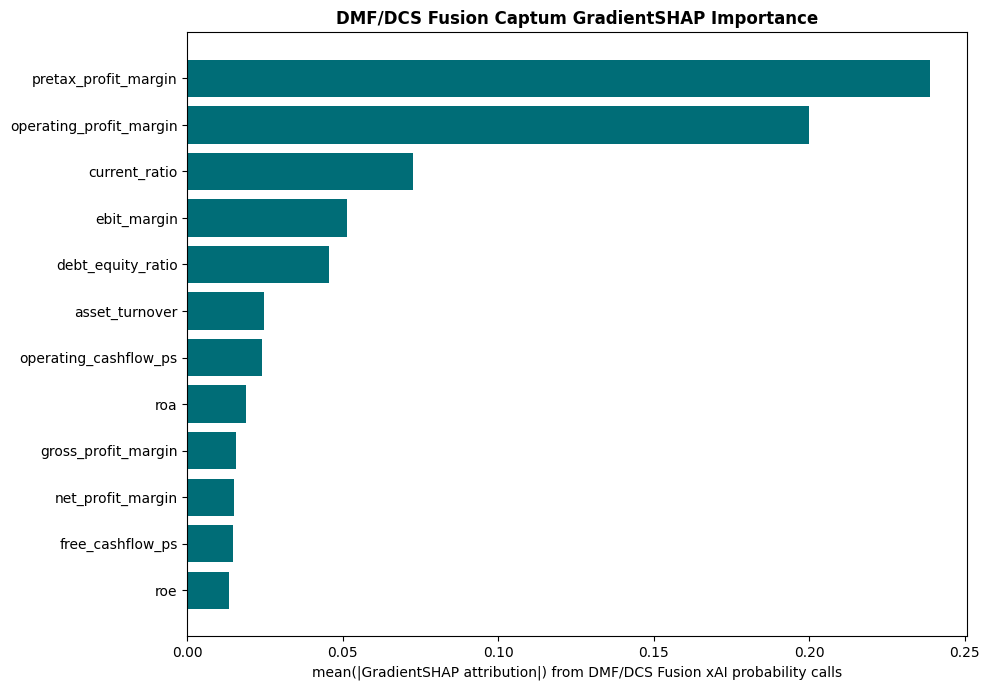

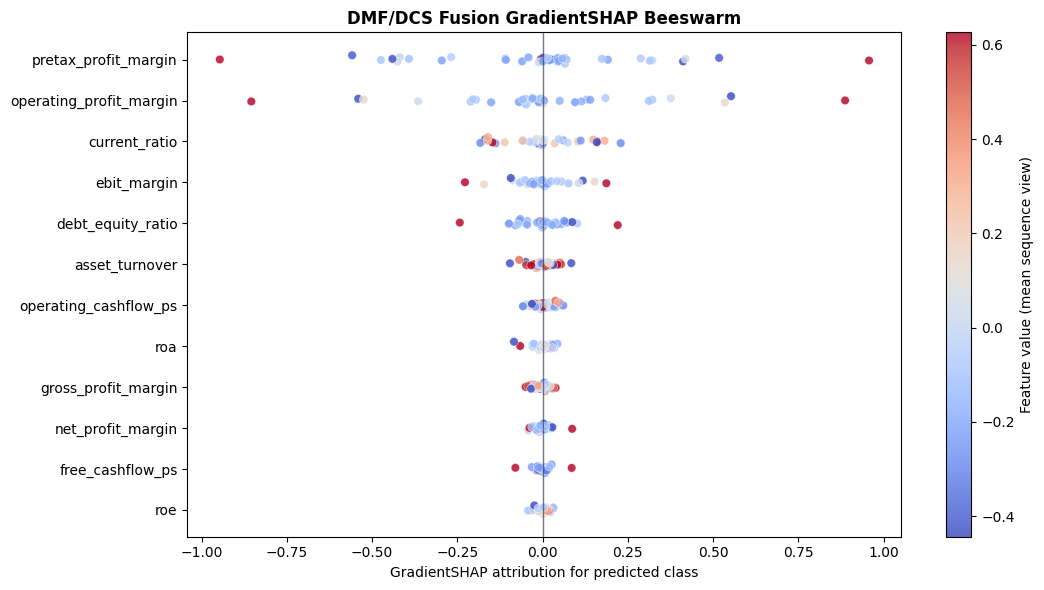


=== Captum GradientSHAP: Why this class? ===

--- Test index 1505 | DMF/DCS Fusion predicted class=0 | predicted_proba=0.9884 ---
Why this class? class=0 | model_proba=0.9884
  opposes_explained_class    | ebit_margin                                   | attribution=-0.01028
  opposes_explained_class    | asset_turnover                                | attribution=-0.00744
  opposes_explained_class    | current_ratio                                 | attribution=-0.00711
  opposes_explained_class    | net_profit_margin                             | attribution=-0.00459
  supports_explained_class   | operating_cashflow_ps                         | attribution=+0.00363
Why this class? class=1 | model_proba=0.0072
  opposes_explained_class    | pretax_profit_margin                          | attribution=-0.32372
  supports_explained_class   | operating_profit_margin                       | attribution=+0.26137
  supports_explained_class   | gross_profit_margin                           | 

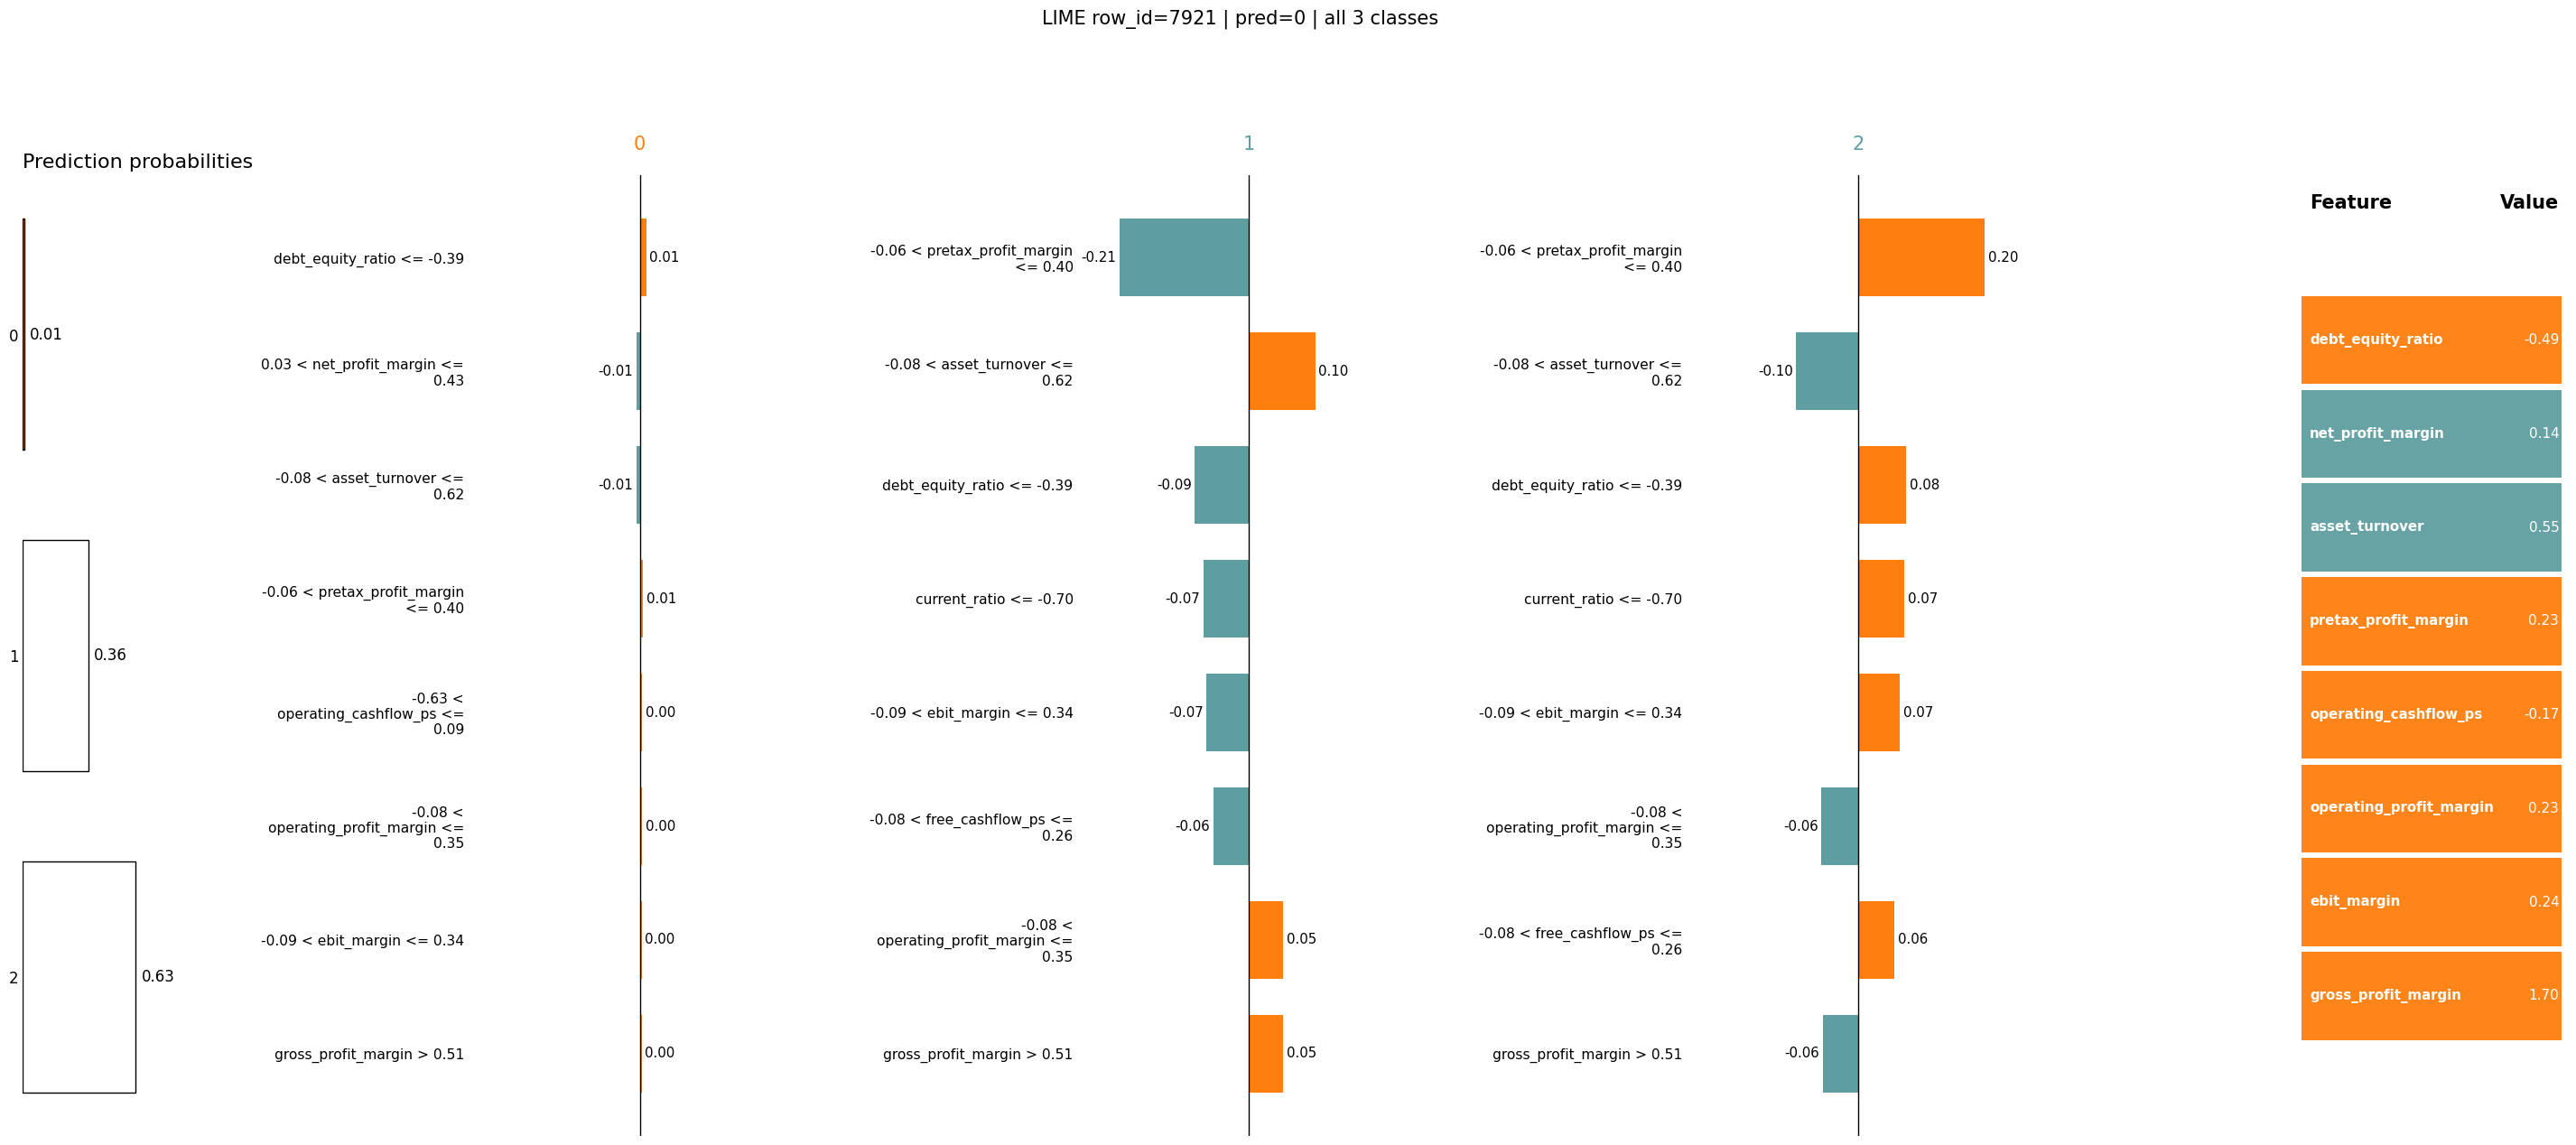

Why this class? class=0 | model_proba=0.9884 | lime_proba=0.0053
  supports_explained_class   | debt_equity_ratio <= -0.39                    | weight=+0.01004
  opposes_explained_class    | 0.03 < net_profit_margin <= 0.43              | weight=-0.00555
  opposes_explained_class    | -0.08 < asset_turnover <= 0.62                | weight=-0.00523
  supports_explained_class   | -0.06 < pretax_profit_margin <= 0.40          | weight=+0.00509
  supports_explained_class   | -0.63 < operating_cashflow_ps <= 0.09         | weight=+0.00345
Why this class? class=1 | model_proba=0.0072 | lime_proba=0.3647
  opposes_explained_class    | -0.06 < pretax_profit_margin <= 0.40          | weight=-0.20636
  supports_explained_class   | -0.08 < asset_turnover <= 0.62                | weight=+0.10490
  opposes_explained_class    | debt_equity_ratio <= -0.39                    | weight=-0.08629
  opposes_explained_class    | current_ratio <= -0.70                        | weight=-0.07297
  opposes_expla

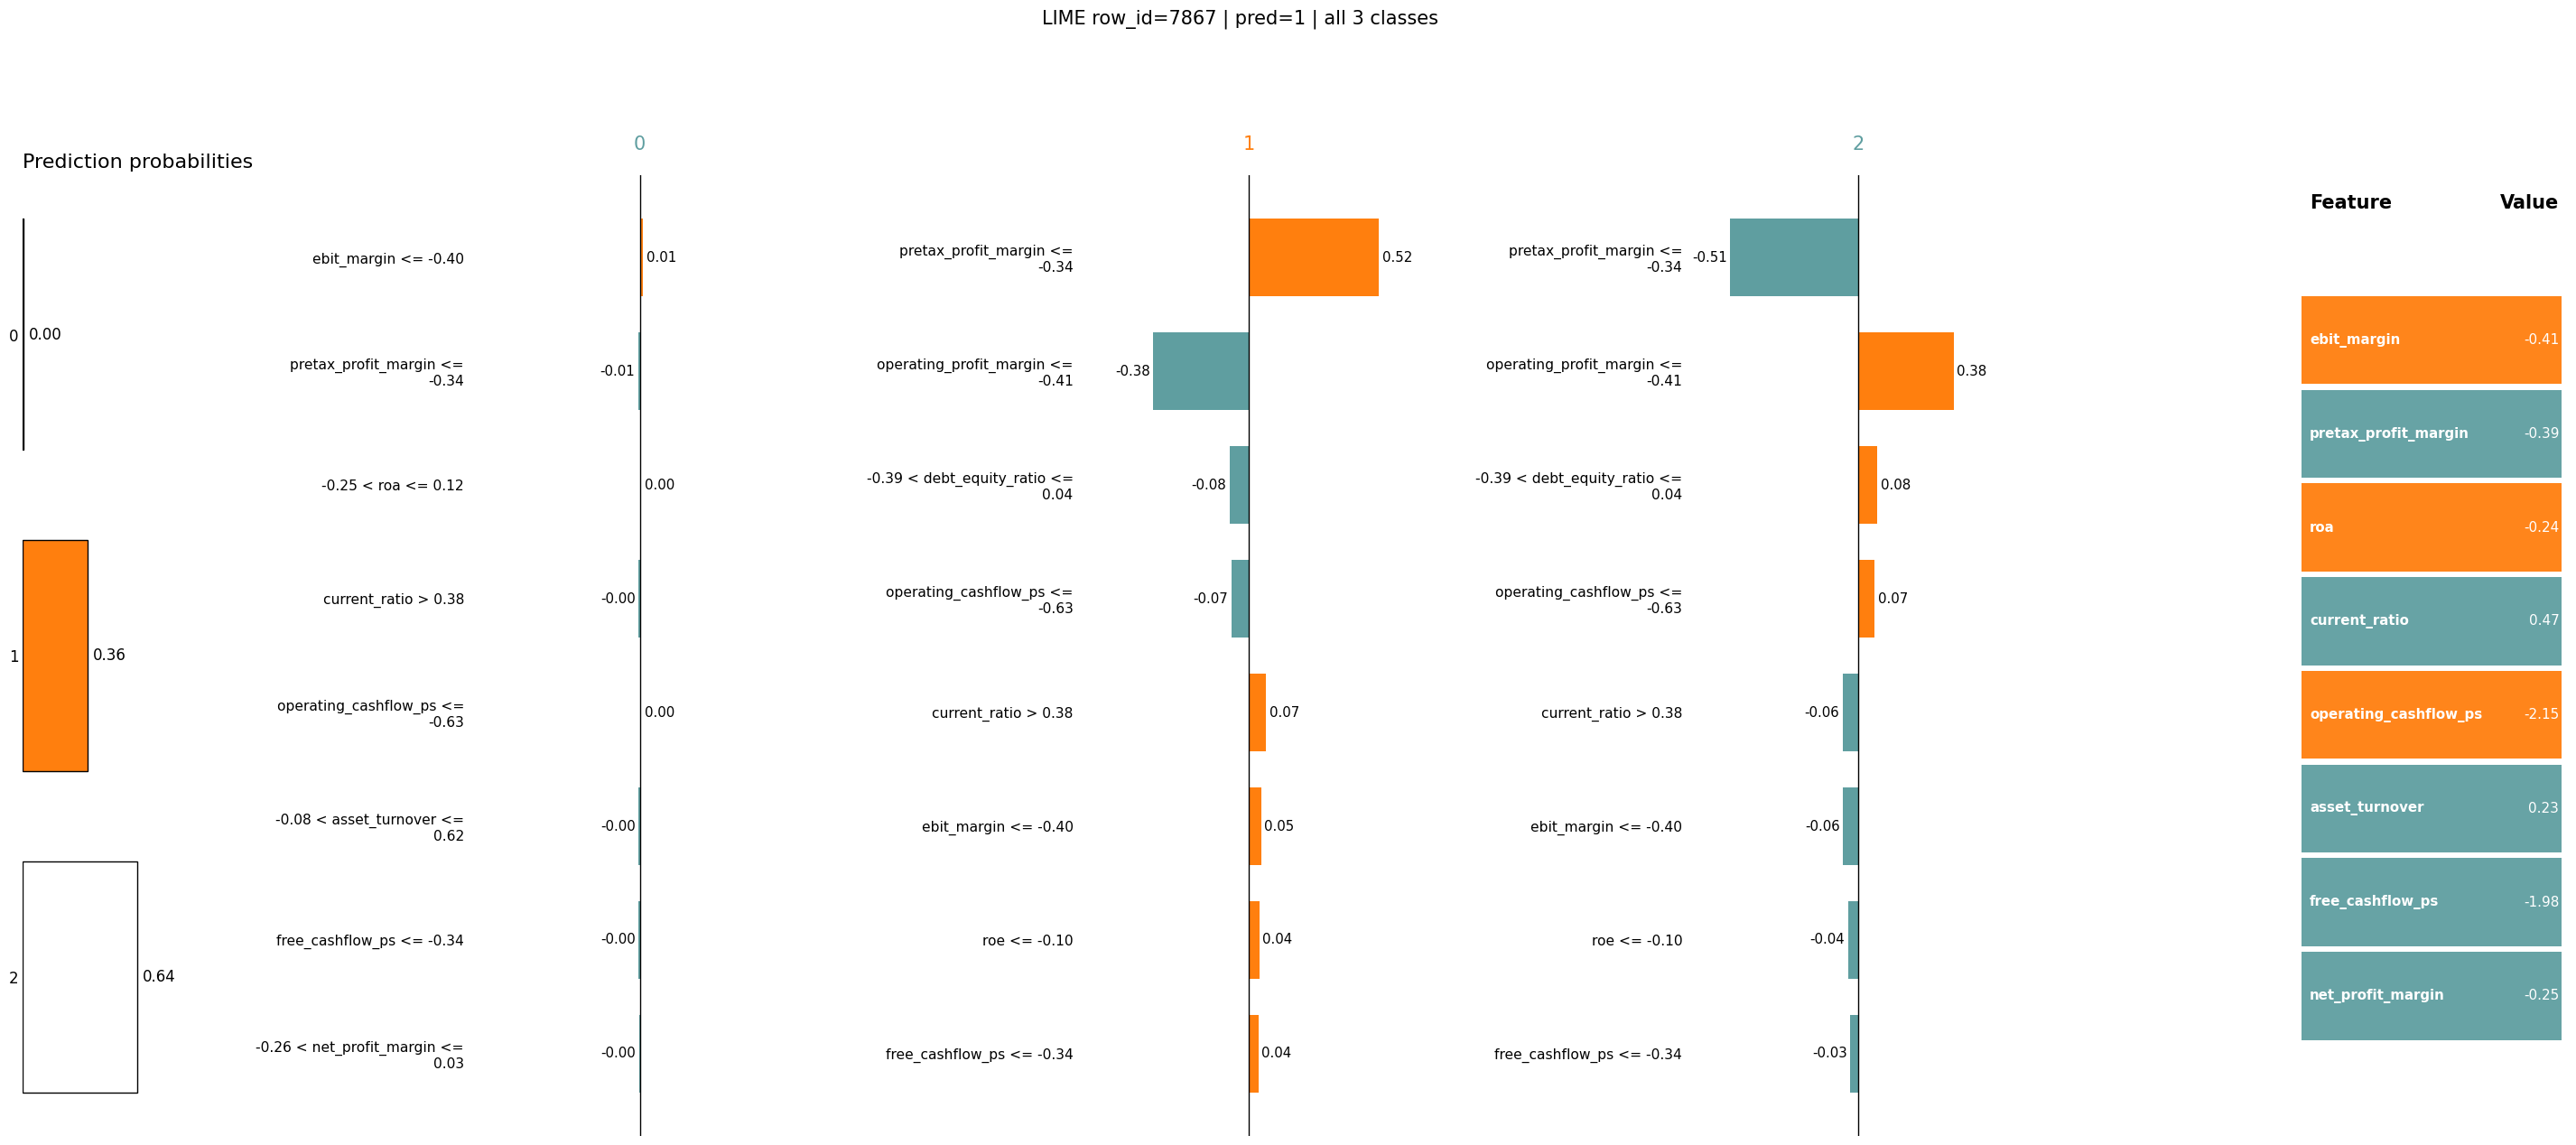

Why this class? class=0 | model_proba=0.0028 | lime_proba=0.0015
  supports_explained_class   | ebit_margin <= -0.40                          | weight=+0.01281
  opposes_explained_class    | pretax_profit_margin <= -0.34                 | weight=-0.00710
  supports_explained_class   | -0.25 < roa <= 0.12                           | weight=+0.00499
  opposes_explained_class    | current_ratio > 0.38                          | weight=-0.00491
  supports_explained_class   | operating_cashflow_ps <= -0.63                | weight=+0.00468
Why this class? class=1 | model_proba=0.9887 | lime_proba=0.3605
  supports_explained_class   | pretax_profit_margin <= -0.34                 | weight=+0.51586
  opposes_explained_class    | operating_profit_margin <= -0.41              | weight=-0.38067
  opposes_explained_class    | -0.39 < debt_equity_ratio <= 0.04             | weight=-0.07672
  opposes_explained_class    | operating_cashflow_ps <= -0.63                | weight=-0.06998
  supports_expl

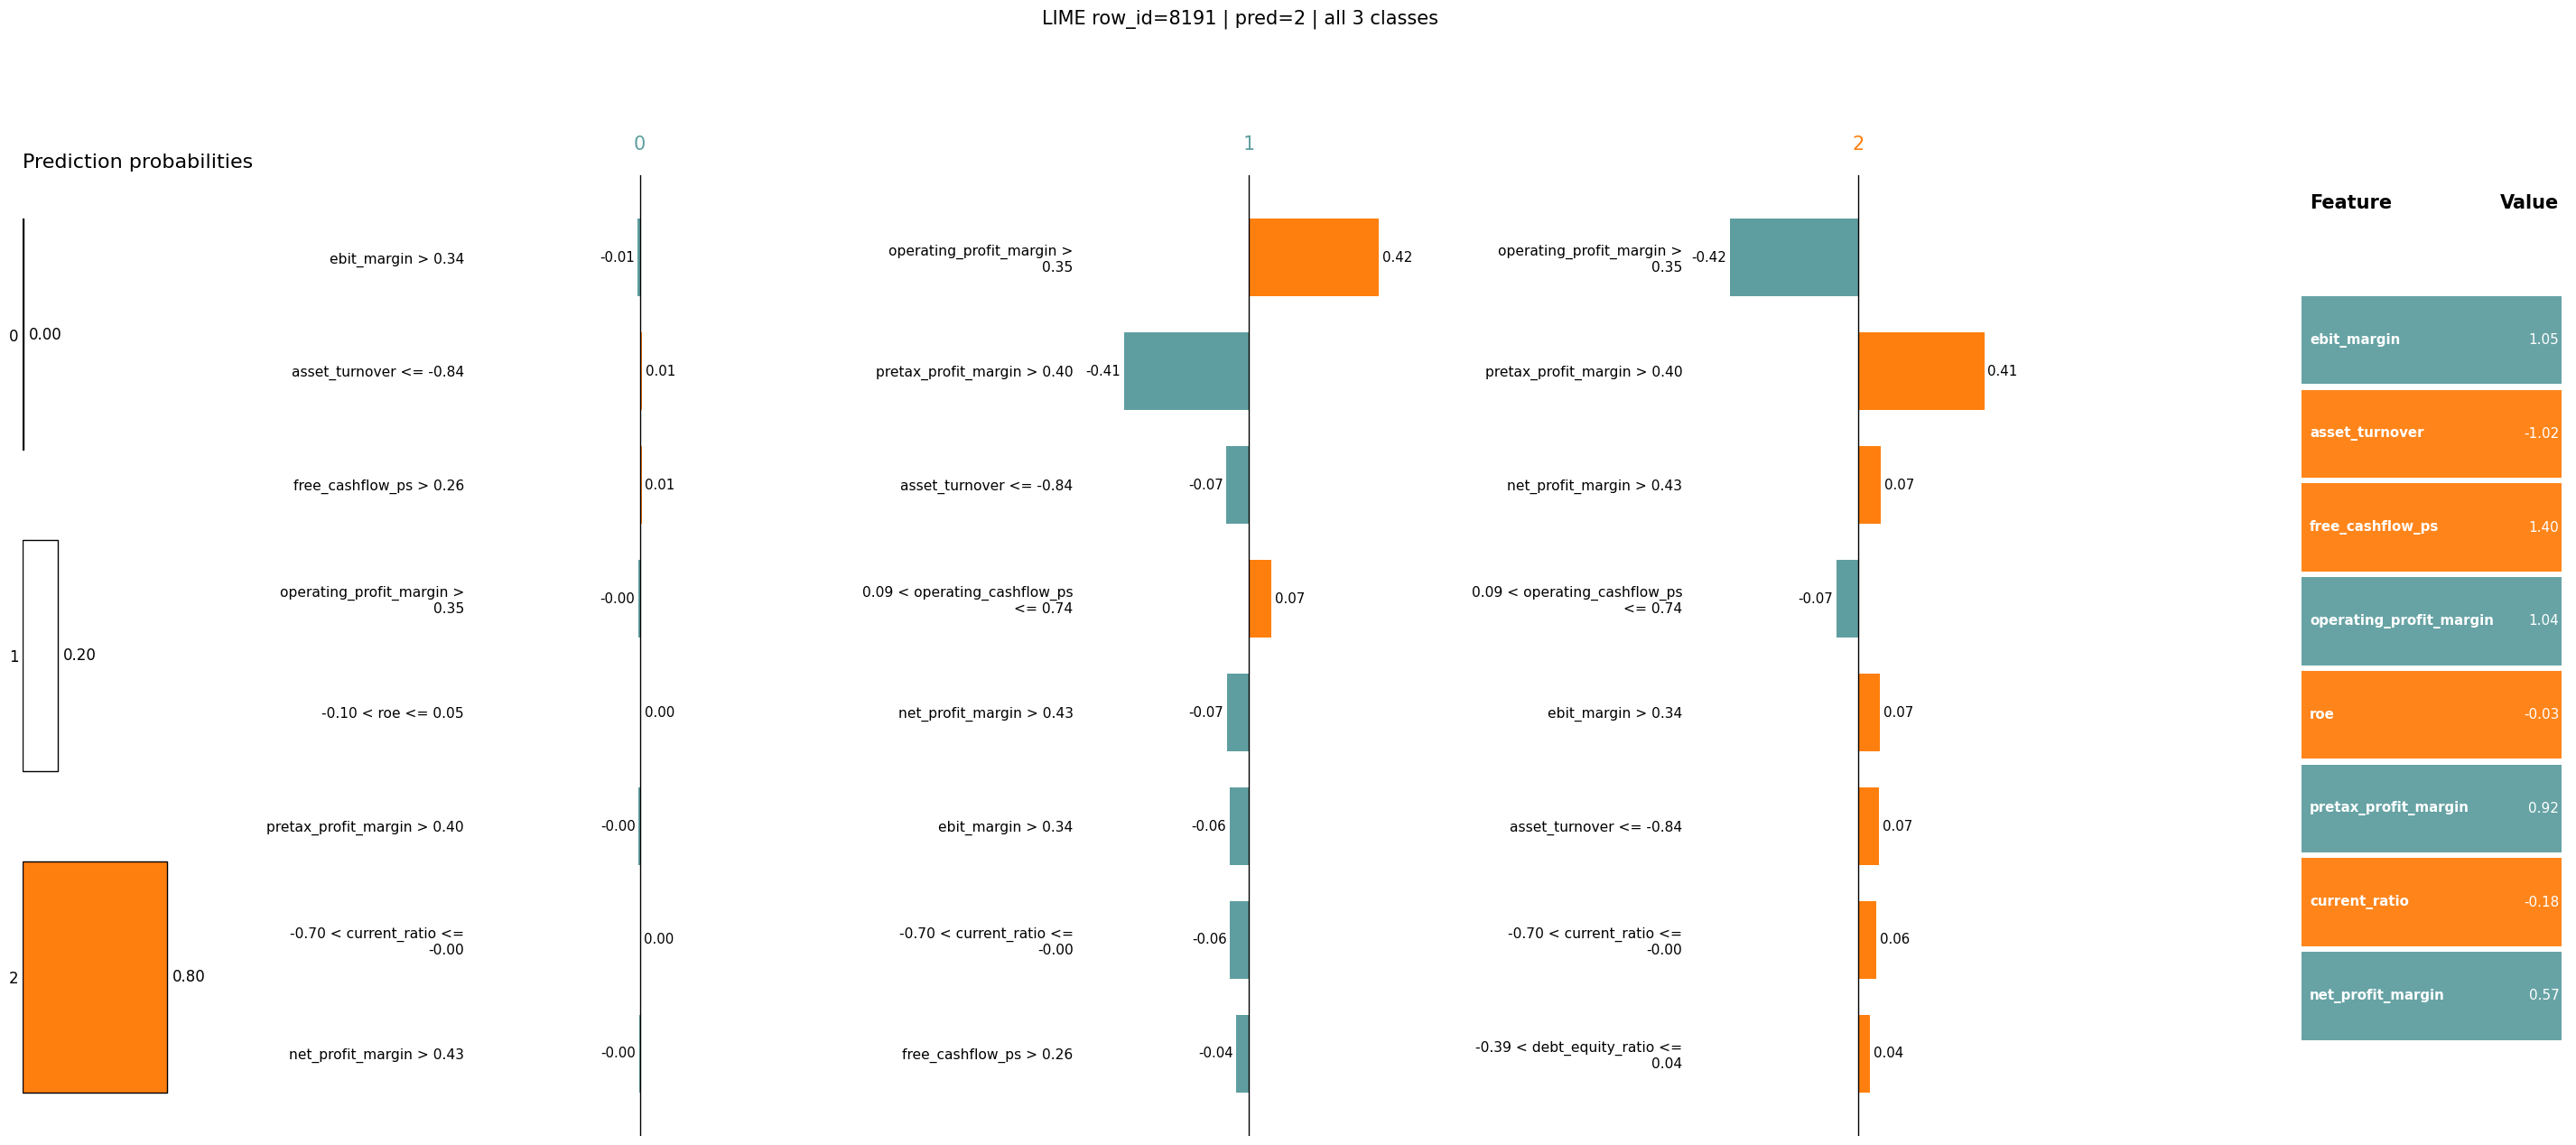

Why this class? class=0 | model_proba=0.0004 | lime_proba=0.0013
  opposes_explained_class    | ebit_margin > 0.34                            | weight=-0.00732
  supports_explained_class   | asset_turnover <= -0.84                       | weight=+0.00652
  supports_explained_class   | free_cashflow_ps > 0.26                       | weight=+0.00621
  opposes_explained_class    | operating_profit_margin > 0.35                | weight=-0.00470
  supports_explained_class   | -0.10 < roe <= 0.05                           | weight=+0.00460
Why this class? class=1 | model_proba=0.0027 | lime_proba=0.1950
  supports_explained_class   | operating_profit_margin > 0.35                | weight=+0.42122
  opposes_explained_class    | pretax_profit_margin > 0.40                   | weight=-0.40501
  opposes_explained_class    | asset_turnover <= -0.84                       | weight=-0.07395
  supports_explained_class   | 0.09 < operating_cashflow_ps <= 0.74          | weight=+0.07228
  opposes_expla

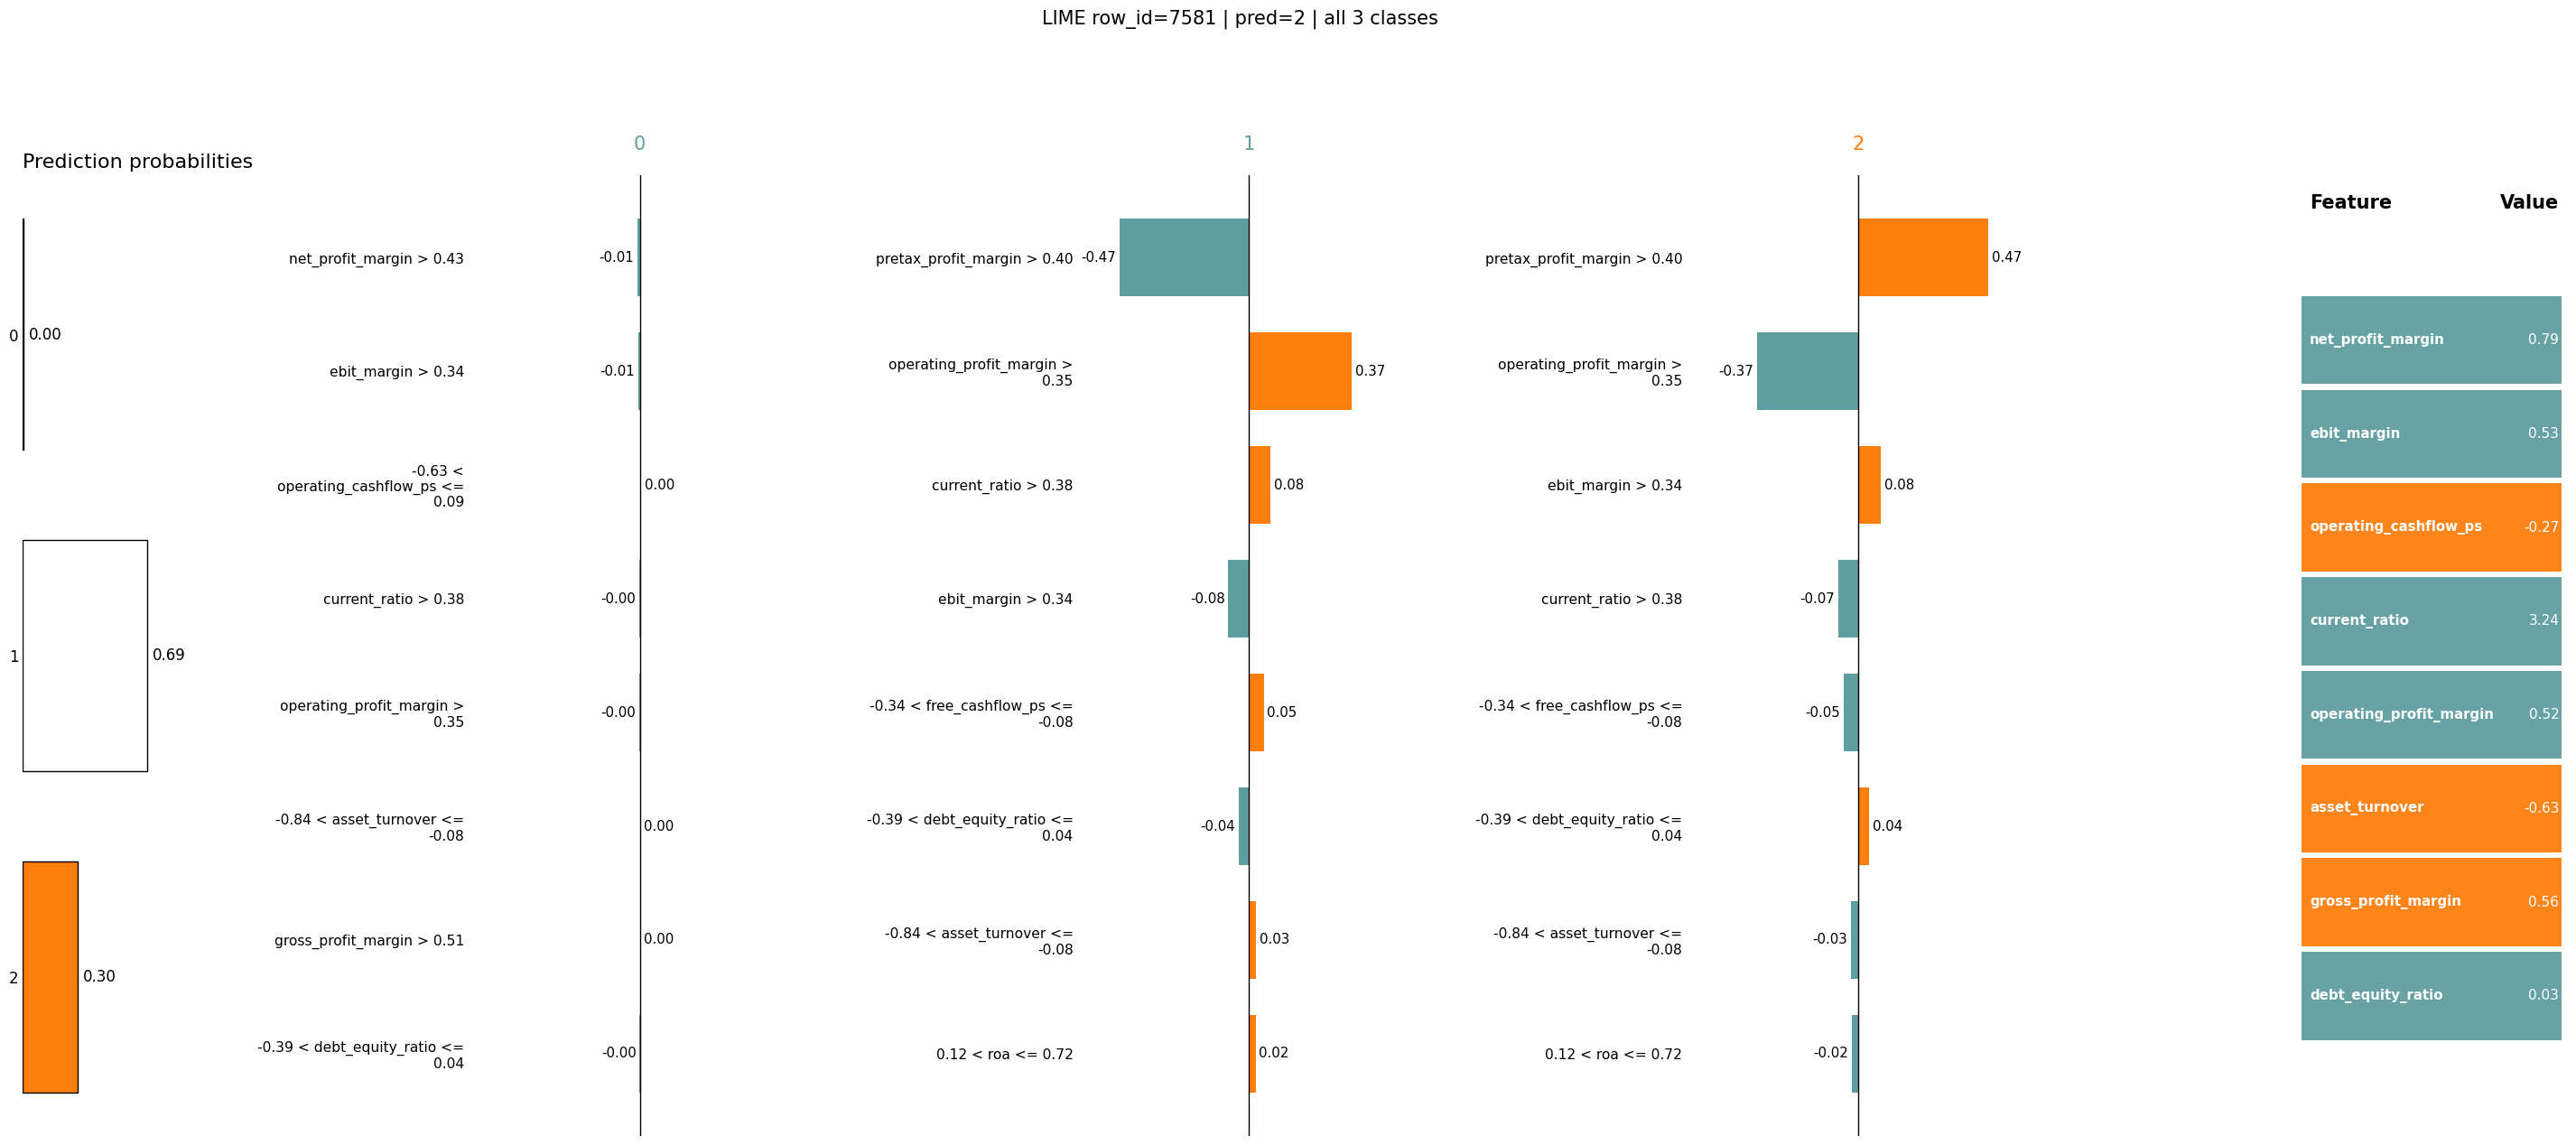

Why this class? class=0 | model_proba=0.0000 | lime_proba=0.0028
  opposes_explained_class    | net_profit_margin > 0.43                      | weight=-0.00867
  opposes_explained_class    | ebit_margin > 0.34                            | weight=-0.00719
  supports_explained_class   | -0.63 < operating_cashflow_ps <= 0.09         | weight=+0.00472
  opposes_explained_class    | current_ratio > 0.38                          | weight=-0.00388
  opposes_explained_class    | operating_profit_margin > 0.35                | weight=-0.00350
Why this class? class=1 | model_proba=0.0033 | lime_proba=0.6941
  opposes_explained_class    | pretax_profit_margin > 0.40                   | weight=-0.47180
  supports_explained_class   | operating_profit_margin > 0.35                | weight=+0.37331
  supports_explained_class   | current_ratio > 0.38                          | weight=+0.07830
  opposes_explained_class    | ebit_margin > 0.34                            | weight=-0.07605
  supports_expl

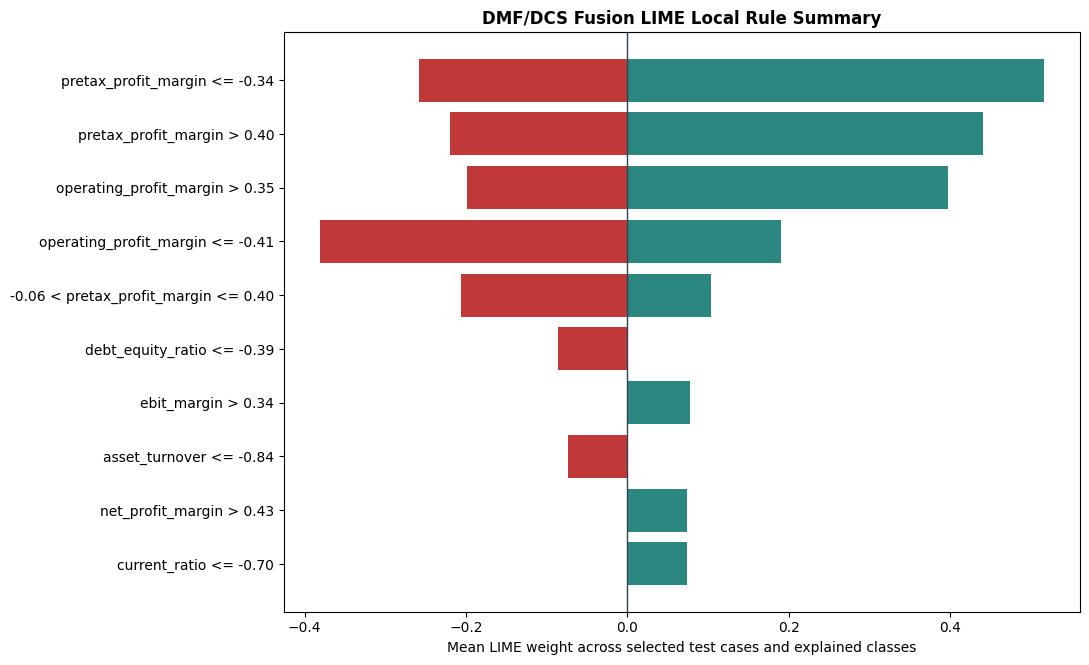

Saved: /kaggle/working/credit_rating_artifacts/dmf_dcs_financial_lime_rule_summary.png
Saved per-class local LIME decision explanations to: /kaggle/working/credit_rating_artifacts/dmf_dcs_financial_lime_local_decisions.csv


In [9]:
# ============================================================
# xAI Captum GradientSHAP + LIME aligned with Transformer-LSTM presentation
# Main artifacts:
#   {model_key}_financial_shap_importance_by_class.csv
#   {model_key}_financial_shap_global_importance.csv
#   {model_key}_financial_shap_local_decisions.csv
#   {model_key}_financial_lime_local_decisions.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "dmf_dcs"
XAI_MODEL_LABEL = "DMF/DCS Fusion"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_LOCAL_SAMPLE_COUNT = 4
XAI_LOCAL_TOP_FEATURES = 10
XAI_FINANCIAL_REDUCER = "mean"  # {"mean", "last"}; used when reducing sequence windows.
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id list for local case studies.
XAI_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
XAI_PROXY_MAX_ROWS = 2500
XAI_PROXY_EPOCHS = 220
XAI_DEVICE_PREFERENCE = "auto"  # {"auto", "cpu", "cuda"}; CPU fallback avoids unsupported Kaggle CUDA kernels.
LIME_NUM_SAMPLES = 600
LIME_USE_DIRECT_MODEL_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8

import math
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError("xAI GradientSHAP requires PyTorch for the differentiable attribution head.") from exc


def _xai_artifact_dir():
    path = globals().get("ARTIFACT_DIR", globals().get("DMF_ARTIFACT_DIR", None))
    if path is None:
        path = Path("/kaggle/working/credit_rating_artifacts") if globals().get("IN_KAGGLE", False) else Path("credit_rating_artifacts")
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_class_names(n_cls):
    if "class_names" in globals() and len(class_names) > 0:
        names = [str(x) for x in class_names]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    if "id_to_name" in globals():
        return [str(id_to_name.get(i, i)) for i in range(n_cls)]
    if "id_to_raw" in globals():
        return [str(id_to_raw.get(i, i)) for i in range(n_cls)]
    if "raw_to_id" in globals():
        inv = {int(v): k for k, v in raw_to_id.items()}
        return [str(inv.get(i, i)) for i in range(n_cls)]
    if "le" in globals() and hasattr(le, "classes_"):
        names = [str(x) for x in le.classes_]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    return [str(i) for i in range(n_cls)]


def _xai_resolve_class_ids(class_ids, n_cls):
    if class_ids is None:
        return list(range(n_cls))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_cls:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_cls - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_prob_columns(frame, prefix=None):
    if prefix is None:
        cols = [c for c in frame.columns if str(c).startswith("prob_")]
    else:
        cols = [c for c in frame.columns if str(c).startswith(f"{prefix}_prob_")]

    def suffix_num(name):
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=suffix_num)


def _xai_get_proba():
    for name in ["dmf_probs", "fp", "test_proba", "test_probs", "weighted_probs", "soft_probs", "y_test_proba"]:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2 and arr.shape[0] > 0:
                return _xai_normalize_proba(arr), name
    if "model" in globals() and "X_test" in globals() and hasattr(model, "predict_proba"):
        X_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        return _xai_normalize_proba(model.predict_proba(X_arr)), "model.predict_proba(X_test)"
    for frame_name in ["test_predictions", "test_results", "test_result_df", "test_results_df", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            cols = _xai_prob_columns(frame)
            if cols:
                return _xai_normalize_proba(frame[cols].to_numpy(dtype=float)), frame_name
    raise RuntimeError("Kh?ng t?m th?y probability matrix cho xAI. H?y ch?y cell inference/evaluation tr??c.")



_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]
_XAI_NON_FINANCIAL_EXACT = {
    "row_id", "test_index", "split", "ticker", "company_name", "rating_agency", "rating_date",
    "sector", "source", "rating_detail", "true_label", "true_label_name", "pred_label",
    "pred_label_name", "prediction", "confidence", "selected_model", "dcs_case", "delta_days",
}
_XAI_NON_FINANCIAL_TOKENS = (
    "prob_", "_prob_", "pred_", "_pred_", "confidence", "weight", "score", "delta",
    "k_eff", "reference_count", "case", "model", "label", "class", "rank", "index",
)
_xai_financial_frame_cache = None
_xai_financial_frame_cache_rows = None


def _xai_financial_feature_columns(frame):
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        return []
    canonical = [c for c in _XAI_CANONICAL_FINANCIAL_FEATURES if c in frame.columns]
    if canonical:
        return canonical
    suffixed = [f"{c}_financial" for c in _XAI_CANONICAL_FINANCIAL_FEATURES if f"{c}_financial" in frame.columns]
    return suffixed


def _xai_original_financial_feature_names():
    return list(_XAI_CANONICAL_FINANCIAL_FEATURES)


def _xai_financial_indices_from_names(names):
    names = [str(c) for c in names]
    cols = [c for c in _xai_original_financial_feature_names() if c in names]
    idx = [names.index(c) for c in cols]
    return idx, cols


def _xai_frame_financial_values(frame):
    cols = _xai_financial_feature_columns(frame)
    if not cols:
        return None, []
    X = frame[cols].to_numpy(dtype=np.float64)
    display_cols = [str(c).removesuffix("_financial") for c in cols]
    return X, display_cols


def _xai_reduce_sequence_to_original_financial(seq, candidate_names):
    seq = np.asarray(seq, dtype=np.float64)
    idx, cols = _xai_financial_indices_from_names(candidate_names)
    if idx:
        return seq[:, :, idx].mean(axis=1), cols
    return None, []


def _xai_load_split_test_frame():
    candidates = []
    if "TEST_PATH" in globals():
        candidates.append(Path(globals()["TEST_PATH"]))
    if "PROJECT_ROOT" in globals():
        root = Path(globals()["PROJECT_ROOT"])
        candidates.extend([
            root / "data" / "processed" / "test" / "test.csv",
            root / "data" / "processed" / "test.csv",
        ])
    candidates.extend([
        Path("/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv"),
        Path("data/processed/test/test.csv"),
        Path("data/processed/test.csv"),
    ])
    seen = set()
    for path in candidates:
        path = Path(path)
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        if path.exists():
            try:
                return pd.read_csv(path, encoding="utf-8")
            except UnicodeDecodeError:
                return pd.read_csv(path, encoding="utf-8-sig")
            except Exception as exc:
                print(f"[WARN] Khong doc duoc split test cho xAI tai {path}: {exc}")
    return None


def _xai_frame_has_financials(frame):
    return isinstance(frame, pd.DataFrame) and bool(_xai_financial_feature_columns(frame))


def _xai_reconstruct_index_aligned_test_frame(n_rows):
    if "_y_test_path" not in globals():
        return None
    try:
        y_index_path = Path(globals()["_y_test_path"])
    except Exception:
        return None
    if not y_index_path.exists():
        return None
    try:
        raw_index = np.load(str(y_index_path), allow_pickle=True)
    except Exception:
        return None
    raw_index = np.asarray(raw_index)
    if raw_index.ndim != 1 or len(raw_index) < n_rows:
        return None
    numeric_index = pd.to_numeric(pd.Series(raw_index[:n_rows]), errors="coerce")
    if numeric_index.isna().any():
        return None
    class_count = int(globals().get("n_classes", len(globals().get("class_names", [])) or 0))
    if class_count > 0 and int(numeric_index.max()) < class_count:
        return None
    if not all(name in globals() and isinstance(globals()[name], pd.DataFrame) for name in ["df_train", "df_val", "df_test"]):
        return None
    pieces = [globals()[name] for name in ["df_train", "df_val", "df_test"]]
    target_col = globals().get("TARGET_COL", "rating_detail")
    frame_full = pd.concat(pieces, ignore_index=True)
    if target_col in frame_full.columns:
        frame_full = frame_full.dropna(subset=[target_col]).reset_index(drop=True)
    idx = numeric_index.astype(int).to_numpy()
    if idx.max(initial=-1) >= len(frame_full):
        return None
    aligned = frame_full.iloc[idx].reset_index(drop=True)
    return aligned if _xai_frame_has_financials(aligned) else None


def _xai_merge_financial_split(base_frame, raw_frame, n_rows):
    if not isinstance(base_frame, pd.DataFrame) or not isinstance(raw_frame, pd.DataFrame):
        return None
    if len(base_frame) < n_rows:
        return None
    base = base_frame.reset_index(drop=True).loc[:n_rows - 1].copy()
    raw = raw_frame.reset_index(drop=True).copy()

    if "row_id" in base.columns and "row_id" in raw.columns:
        left = base.copy()
        right = raw.copy()
        left["_xai_row_key"] = left["row_id"].astype(str)
        right["_xai_row_key"] = right["row_id"].astype(str)
        merged = left.merge(right, on="_xai_row_key", how="left", suffixes=("", "_financial"), sort=False)
        if len(merged) == len(base) and _xai_frame_has_financials(merged):
            return merged

    keys = [c for c in ["ticker", "rating_date", "company_name"] if c in base.columns and c in raw.columns]
    if len(keys) >= 2:
        merged = base.merge(raw, on=keys, how="left", suffixes=("", "_financial"), sort=False)
        if len(merged) == len(base) and _xai_frame_has_financials(merged):
            return merged

    if len(raw) >= n_rows and _xai_frame_has_financials(raw):
        print("[WARN] xAI dung thu tu split test de can hang dac trung tai chinh vi khong co khoa merge tuyet doi.")
        return raw.loc[:n_rows - 1].reset_index(drop=True)
    return None


def _xai_aligned_financial_frame(n_rows):
    global _xai_financial_frame_cache, _xai_financial_frame_cache_rows
    if _xai_financial_frame_cache is not None and _xai_financial_frame_cache_rows == n_rows:
        return _xai_financial_frame_cache

    aligned = _xai_reconstruct_index_aligned_test_frame(n_rows)
    if aligned is not None:
        _xai_financial_frame_cache = aligned.reset_index(drop=True).loc[:n_rows - 1].copy()
        _xai_financial_frame_cache_rows = n_rows
        return _xai_financial_frame_cache

    for frame_name in ["df_test", "test_financial_df", "test_rows", "test_df", "out"]:
        frame = globals().get(frame_name)
        if isinstance(frame, pd.DataFrame) and len(frame) >= n_rows and _xai_frame_has_financials(frame):
            if frame_name == "df_test" and "test_probas" in globals():
                print("[WARN] xAI dung df_test de giai thich dac trung tai chinh; hay dam bao thu tu df_test khop artifact du doan.")
            _xai_financial_frame_cache = frame.reset_index(drop=True).loc[:n_rows - 1].copy()
            _xai_financial_frame_cache_rows = n_rows
            return _xai_financial_frame_cache

    raw_test = _xai_load_split_test_frame()
    if raw_test is not None:
        for frame_name in ["test_df", "out", "test_predictions", "test_results_df"]:
            merged = _xai_merge_financial_split(globals().get(frame_name), raw_test, n_rows)
            if merged is not None:
                _xai_financial_frame_cache = merged.reset_index(drop=True).loc[:n_rows - 1].copy()
                _xai_financial_frame_cache_rows = n_rows
                return _xai_financial_frame_cache
        if len(raw_test) >= n_rows and _xai_frame_has_financials(raw_test):
            print("[WARN] xAI dung split test theo thu tu hang de giai thich dac trung tai chinh.")
            _xai_financial_frame_cache = raw_test.reset_index(drop=True).loc[:n_rows - 1].copy()
            _xai_financial_frame_cache_rows = n_rows
            return _xai_financial_frame_cache

    return None

def _xai_get_feature_view(proba):
    aligned_financial = _xai_aligned_financial_frame(len(proba))
    if aligned_financial is not None:
        X_fin, financial_cols = _xai_frame_financial_values(aligned_financial)
        if financial_cols:
            return X_fin, financial_cols, "aligned_original_financial_features"
    if "test_ds" in globals() and hasattr(test_ds, "samples") and len(test_ds.samples) > 0:
        seq = np.stack([s[0] for s in test_ds.samples], axis=0).astype(np.float64)
        candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(seq.shape[-1])]))
        X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(seq, candidate_names)
        if financial_cols:
            return X_fin, financial_cols, "original_financial_sequence_mean"
    if "test_X_all" in globals():
        arr = np.asarray(test_X_all, dtype=np.float64)
        if arr.ndim == 3:
            candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(arr.shape[-1])]))
            X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(arr, candidate_names)
            if financial_cols:
                return X_fin, financial_cols, "original_financial_sequence_mean"
        if arr.ndim == 2:
            candidate_names = globals().get("flat_feature_names", [f"feature_{i}" for i in range(arr.shape[1])])
            idx, financial_cols = _xai_financial_indices_from_names(candidate_names)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_flat_features"
            if "MODEL_FEATURES" in globals() and arr.shape[1] == len(MODEL_FEATURES):
                idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
                if idx:
                    return arr[:, idx], financial_cols, "original_financial_tabular_features"
    if "X_test" in globals():
        if isinstance(X_test, pd.DataFrame):
            X_fin, financial_cols = _xai_frame_financial_values(X_test)
            if financial_cols:
                return X_fin, financial_cols, "original_financial_tabular_features"
            arr = X_test.values
        else:
            arr = np.asarray(X_test)
        arr = np.asarray(arr, dtype=np.float64)
        if "MODEL_FEATURES" in globals() and arr.ndim == 2 and arr.shape[1] == len(MODEL_FEATURES):
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_tabular_features"
        if "MODEL_FEATURES" in globals() and "INPUT_SIZE" in globals() and arr.ndim == 2 and arr.shape[1] >= int(INPUT_SIZE) * len(MODEL_FEATURES):
            n_base = len(MODEL_FEATURES)
            window = arr[:, :int(INPUT_SIZE) * n_base].reshape(arr.shape[0], int(INPUT_SIZE), n_base)
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return window[:, :, idx].mean(axis=1), financial_cols, "original_financial_tabular_window_mean"
        cols = list(X_test.columns) if isinstance(X_test, pd.DataFrame) else [f"feature_{i}" for i in range(arr.shape[1])]
        idx, financial_cols = _xai_financial_indices_from_names(cols)
        if idx:
            return arr[:, idx], financial_cols, "original_financial_tabular_features"
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        X_fin, financial_cols = _xai_frame_financial_values(frame)
        if financial_cols:
            return X_fin, financial_cols, "df_test_mask_original_financial_features"
    for frame_name in ["test_df", "df_test", "test_rows", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            X_fin, financial_cols = _xai_frame_financial_values(frame)
            if financial_cols:
                return X_fin, financial_cols, f"{frame_name}_original_financial_features"
            prob_cols = []
            for prefix in ["tlstm", "gat", "lstm", "tcn", "patchtst", "xgboost", "lightgbm", "dmf"]:
                prob_cols.extend(_xai_prob_columns(frame, prefix=prefix))
            if prob_cols:
                return frame[prob_cols].to_numpy(dtype=np.float64), [str(c) for c in prob_cols], f"{frame_name}_probability_inputs"
    if "test_probas" in globals() and isinstance(test_probas, list) and len(test_probas) > 0:
        mats = [np.asarray(p, dtype=np.float64) for p in test_probas]
        if all(m.ndim == 2 for m in mats):
            names = globals().get("MODEL_NAMES", [f"model_{i}" for i in range(len(mats))])
            feature_cols = []
            for model_name, mat in zip(names, mats):
                for class_idx in range(mat.shape[1]):
                    feature_cols.append(f"{model_name}_prob_{class_idx}")
            return np.concatenate(mats, axis=1), feature_cols, "ensemble_probability_inputs"
    return np.asarray(proba, dtype=np.float64), [f"predicted_prob_{i}" for i in range(proba.shape[1])], "model_probability_vector"


def _xai_metadata(n_rows):
    meta_cols = ["row_id", "ticker", "company_name", "rating_date", "sector", "true_label", "true_label_name"]
    aligned_financial = globals().get("_xai_financial_frame_cache", None)
    if isinstance(aligned_financial, pd.DataFrame) and len(aligned_financial) >= n_rows:
        cols = [c for c in meta_cols if c in aligned_financial.columns]
        if cols:
            return aligned_financial.reset_index(drop=True).loc[:n_rows - 1, cols].copy()
    for frame_name in ["test_df", "df_test", "test_rows", "out", "test_predictions", "test_results_df"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame) and len(globals()[frame_name]) >= n_rows:
            frame = globals()[frame_name].reset_index(drop=True)
            cols = [c for c in meta_cols if c in frame.columns]
            if cols:
                return frame.loc[:n_rows - 1, cols].copy()
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        cols = [c for c in meta_cols if c in frame.columns]
        if cols and len(frame) >= n_rows:
            return frame.loc[:n_rows - 1, cols].copy()
    meta = pd.DataFrame({"test_index": np.arange(n_rows, dtype=int)})
    if "y_test" in globals() and len(y_test) >= n_rows:
        meta["true_label"] = np.asarray(y_test[:n_rows], dtype=int)
    elif "y_true" in globals() and len(y_true) >= n_rows:
        meta["true_label"] = np.asarray(y_true[:n_rows], dtype=int)
    return meta


def _xai_select_indices(meta, proba):
    n_rows = len(meta)
    if XAI_ROW_IDS is not None and "row_id" in meta.columns:
        wanted = {str(x) for x in XAI_ROW_IDS}
        idx = [int(i) for i, row_id in enumerate(meta["row_id"].astype(str)) if row_id in wanted]
        if idx:
            return idx[:XAI_LOCAL_SAMPLE_COUNT]
    confidence = proba.max(axis=1)
    ranked = np.argsort(-confidence)
    selected = []
    preds = proba.argmax(axis=1)
    for class_id in np.unique(preds[ranked]):
        class_ranked = [int(i) for i in ranked if preds[i] == class_id]
        if class_ranked:
            selected.append(class_ranked[0])
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    for i in ranked:
        i = int(i)
        if i not in selected:
            selected.append(i)
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    return selected


class _XAIProbabilityHead(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        hidden = int(min(96, max(16, 2 * n_features)))
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x.float()), dim=1)


def _xai_resolve_torch_device():
    pref = str(globals().get("XAI_DEVICE_PREFERENCE", "auto")).lower().strip()
    if pref not in {"auto", "cpu", "cuda"}:
        raise ValueError("XAI_DEVICE_PREFERENCE must be one of {'auto', 'cpu', 'cuda'}.")
    if pref == "cpu":
        return torch.device("cpu")
    if not torch.cuda.is_available():
        if pref == "cuda":
            print("[WARN] XAI_DEVICE_PREFERENCE='cuda' nhưng CUDA không khả dụng; dùng CPU cho xAI.")
        return torch.device("cpu")
    try:
        device = torch.device("cuda")
        probe = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 2)).to(device)
        with torch.no_grad():
            _ = probe(torch.zeros((1, 2), dtype=torch.float32, device=device)).detach().cpu()
        return device
    except Exception as exc:
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        print(f"[WARN] CUDA không chạy được cho xAI ({type(exc).__name__}: {exc}); chuyển probability head sang CPU.")
        return torch.device("cpu")


def _xai_train_probability_head(X_view, proba):
    rng = np.random.default_rng(XAI_RANDOM_STATE)
    X_view = np.asarray(X_view, dtype=np.float64)
    proba = _xai_normalize_proba(proba)
    center = np.nanmedian(X_view, axis=0)
    scale = np.nanstd(X_view, axis=0)
    scale = np.where(scale < 1e-8, 1.0, scale)
    X_std = np.nan_to_num((X_view - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
    n_rows = len(X_std)
    fit_idx = np.arange(n_rows)
    if n_rows > XAI_PROXY_MAX_ROWS:
        fit_idx = rng.choice(n_rows, size=XAI_PROXY_MAX_ROWS, replace=False)
    def fit_on_device(device_xai):
        head = _XAIProbabilityHead(X_std.shape[1], proba.shape[1]).to(device_xai)
        x_train = torch.tensor(X_std[fit_idx], dtype=torch.float32, device=device_xai)
        y_train = torch.tensor(proba[fit_idx], dtype=torch.float32, device=device_xai)
        opt = torch.optim.AdamW(head.parameters(), lr=0.01, weight_decay=1e-4)
        head.train()
        for _ in range(int(XAI_PROXY_EPOCHS)):
            opt.zero_grad(set_to_none=True)
            pred = head(x_train)
            loss = torch.mean((pred - y_train) ** 2)
            loss.backward()
            opt.step()
        return head

    device_xai = _xai_resolve_torch_device()
    try:
        head = fit_on_device(device_xai)
    except Exception as exc:
        if device_xai.type != "cuda":
            raise
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        print(f"[WARN] xAI probability head lỗi CUDA khi huấn luyện ({type(exc).__name__}: {exc}); huấn luyện lại trên CPU.")
        device_xai = torch.device("cpu")
        head = fit_on_device(device_xai)
    head.eval()
    with torch.no_grad():
        pred_all = head(torch.tensor(X_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    fidelity = {
        "proxy_mse": float(np.mean((pred_all - proba) ** 2)),
        "proxy_argmax_agreement": float(np.mean(pred_all.argmax(axis=1) == proba.argmax(axis=1))),
    }
    return head, X_std.astype(np.float32), center, scale, device_xai, fidelity


def _xai_predict_from_head(head, center, scale, device_xai, x_batch):
    x_batch = np.asarray(x_batch, dtype=np.float64)
    if x_batch.ndim == 1:
        x_batch = x_batch.reshape(1, -1)
    x_std = np.nan_to_num((x_batch - center) / scale, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    with torch.no_grad():
        pred = head(torch.tensor(x_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    return _xai_normalize_proba(pred)


def _xai_gradientshap_attributions(head, X_std, sample_indices, background_indices, class_ids, device_xai):
    x_samples = torch.tensor(X_std[sample_indices], dtype=torch.float32, device=device_xai)
    baselines = torch.tensor(X_std[background_indices], dtype=torch.float32, device=device_xai)
    method = "captum_gradientshap_probability_head"
    attributions = {}
    try:
        from captum.attr import GradientShap
        gs = GradientShap(head)
        for class_id in class_ids:
            attr = gs.attribute(
                x_samples,
                baselines=baselines,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            attributions[int(class_id)] = attr.detach().cpu().numpy()
    except Exception as exc:
        method = f"expected_gradients_fallback: {type(exc).__name__}"
        rng = np.random.default_rng(XAI_RANDOM_STATE)
        for class_id in class_ids:
            rows = []
            for x_np in X_std[sample_indices]:
                accum = []
                for _ in range(int(GRADIENT_SHAP_N_SAMPLES)):
                    b_np = X_std[int(rng.choice(background_indices))]
                    alpha = float(rng.uniform(0.0, 1.0))
                    noise = rng.normal(0.0, float(GRADIENT_SHAP_STDEV), size=x_np.shape).astype(np.float32)
                    interp_np = b_np + alpha * (x_np - b_np) + noise
                    interp = torch.tensor(interp_np.reshape(1, -1), dtype=torch.float32, device=device_xai, requires_grad=True)
                    score = head(interp)[:, int(class_id)].sum()
                    grad = torch.autograd.grad(score, interp)[0].detach().cpu().numpy()[0]
                    accum.append((x_np - b_np) * grad)
                rows.append(np.mean(accum, axis=0))
            attributions[int(class_id)] = np.asarray(rows, dtype=np.float32)
    return attributions, method


def _xai_lime_fallback(x_row, predict_fn, class_id, feature_names, num_features):
    rng = np.random.default_rng(XAI_RANDOM_STATE + int(class_id))
    x_row = np.asarray(x_row, dtype=np.float64)
    perturb = rng.normal(loc=x_row, scale=np.maximum(np.nanstd(x_row), 1e-3), size=(int(LIME_NUM_SAMPLES), len(x_row)))
    perturb[0] = x_row
    probs = _xai_normalize_proba(predict_fn(perturb))[:, int(class_id)]
    distances = np.linalg.norm(perturb - x_row.reshape(1, -1), axis=1)
    kernel_width = math.sqrt(len(x_row)) * 0.75
    weights = np.exp(-(distances ** 2) / max(kernel_width ** 2, 1e-9))
    X_aug = np.column_stack([np.ones(len(perturb)), perturb - x_row.reshape(1, -1)])
    W = np.sqrt(weights).reshape(-1, 1)
    coef = np.linalg.lstsq(X_aug * W, probs * W.ravel(), rcond=None)[0][1:]
    order = np.argsort(-np.abs(coef))[:num_features]
    return [(str(feature_names[j]), float(coef[j])) for j in order]



def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text

def _xai_save_lime_multiclass_instance_plot(row_meta, exp, model_proba, lime_proba, x_row, html_path, lime_available):
    from matplotlib.patches import Rectangle

    row_id = str(row_meta.get("row_id", row_meta.get("test_index", "unknown")))
    safe_row_id = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in row_id)
    class_ids = list(explain_class_ids)
    if lime_available and exp is not None:
        class_items = {
            int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
            for class_id in class_ids
        }
    else:
        class_items = {
            int(class_id): _xai_lime_fallback(x_row, _xai_probability_fn, int(class_id), feature_cols, min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES)))
            for class_id in class_ids
        }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names_xai))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names_xai))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names_xai], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names_xai[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_cols)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_cols:
                feat_value = float(x_row[feature_cols.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    title = f"LIME row_id={row_id} | pred={class_names_xai[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{safe_row_id}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


proba, proba_source = _xai_get_proba()
X_view, feature_cols, feature_source = _xai_get_feature_view(proba)
X_view = np.asarray(X_view, dtype=np.float64)
n_rows = min(len(X_view), len(proba))
X_view = X_view[:n_rows]
proba = proba[:n_rows]
class_names_xai = _xai_class_names(proba.shape[1])
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS, proba.shape[1])
meta = _xai_metadata(n_rows).reset_index(drop=True)
selected_indices = _xai_select_indices(meta, proba)
background_size = min(int(XAI_BACKGROUND_SIZE), n_rows)
rng = np.random.default_rng(XAI_RANDOM_STATE)
background_indices = rng.choice(n_rows, size=background_size, replace=False) if n_rows > background_size else np.arange(n_rows)
grad_sample_size = min(int(SHAP_MAX_SAMPLES), n_rows)
grad_sample_indices = rng.choice(n_rows, size=grad_sample_size, replace=False) if n_rows > grad_sample_size else np.arange(n_rows)

print(f"[INFO] xAI for {XAI_MODEL_LABEL}: rows={n_rows}, feature_source={feature_source}, probability_source={proba_source}")
print("[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.")
print("[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.")
print("[INFO] Explained classes:", [class_names_xai[i] for i in explain_class_ids])

xai_head, X_std, xai_center, xai_scale, xai_device, proxy_fidelity = _xai_train_probability_head(X_view, proba)
print("[INFO] xAI probability-head fidelity:", proxy_fidelity)


def _xai_probability_fn(x_batch):
    return _xai_predict_from_head(xai_head, xai_center, xai_scale, xai_device, x_batch)

if SHAP_FINANCIAL_ENABLED:
    attrs_by_class, gradientshap_method = _xai_gradientshap_attributions(
        xai_head, X_std, grad_sample_indices, background_indices, explain_class_ids, xai_device
    )
    global_rows = []
    for class_id, attrs in attrs_by_class.items():
        mean_abs = np.mean(np.abs(attrs), axis=0)
        signed = np.mean(attrs, axis=0)
        for rank, j in enumerate(np.argsort(-mean_abs), start=1):
            global_rows.append({
                "rank": int(rank), "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                "class_id": int(class_id), "class_name": class_names_xai[class_id],
                "feature": str(feature_cols[j]), "mean_abs_gradientshap": float(mean_abs[j]),
                "mean_signed_gradientshap": float(signed[j]), "feature_source": feature_source,
                "probability_source": proba_source, "gradientshap_method": gradientshap_method,
                "xai_method": "captum_gradient_shap" if "captum" in gradientshap_method else "expected_gradients_fallback",
                "xai_probability_source": proba_source,
                "proxy_mse": proxy_fidelity["proxy_mse"], "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
            })
    gradient_global_df = pd.DataFrame(global_rows)
    shap_importance_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    gradient_global_df.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global = (
        gradient_global_df.groupby("feature", as_index=False)
        .agg(mean_abs_shap_value=("mean_abs_gradientshap", "mean"), mean_signed_shap_value=("mean_signed_gradientshap", "mean"))
        .sort_values("mean_abs_shap_value", ascending=False)
        .reset_index(drop=True)
    )
    shap_global["rank"] = np.arange(1, len(shap_global) + 1)
    shap_global["model_key"] = XAI_MODEL_KEY
    shap_global["model_label"] = XAI_MODEL_LABEL
    shap_global["feature_source"] = feature_source
    shap_global["probability_source"] = proba_source
    shap_global["xai_probability_source"] = proba_source
    shap_global_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    top_global = shap_global.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"][::-1], top_global["mean_abs_shap_value"][::-1], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel(f"mean(|GradientSHAP attribution|) from {XAI_MODEL_LABEL} xAI probability calls")
    plt.tight_layout()
    shap_bar_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(XAI_BEESWARM_TOP_FEATURES, len(shap_global)))["feature"].tolist()
    beeswarm_idx = [feature_cols.index(f) for f in beeswarm_features if f in feature_cols]
    if beeswarm_idx:
        beeswarm_rows = []
        for class_id, attrs in attrs_by_class.items():
            for local_pos, row_idx in enumerate(grad_sample_indices):
                for feat_idx in beeswarm_idx:
                    beeswarm_rows.append({
                        "class_name": class_names_xai[class_id],
                        "feature": feature_cols[feat_idx],
                        "feature_value": float(X_view[row_idx, feat_idx]),
                        "shap_value": float(attrs[local_pos, feat_idx]),
                    })
        beeswarm_df = pd.DataFrame(beeswarm_rows)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        y_positions = {feature: pos for pos, feature in enumerate(reversed(beeswarm_features))}
        for feature in beeswarm_features:
            subset = beeswarm_df[beeswarm_df["feature"] == feature]
            if subset.empty:
                continue
            jitter = np.random.default_rng(XAI_RANDOM_STATE).normal(0, 0.05, size=len(subset))
            plt.scatter(subset["shap_value"], y_positions[feature] + jitter, c=subset["feature_value"], cmap="coolwarm", s=38, alpha=0.82, edgecolors="white", linewidths=0.35)
        plt.yticks(list(y_positions.values()), list(y_positions.keys()))
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        plt.xlabel("GradientSHAP attribution for predicted class")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        beeswarm_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(_xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

    local_rows = []
    print()
    print("=== Captum GradientSHAP: Why this class? ===")
    selected_attr_lookup = {}
    selected_attrs, selected_method = _xai_gradientshap_attributions(
        xai_head, X_std, selected_indices, background_indices, explain_class_ids, xai_device
    )
    for pos, idx in enumerate(selected_indices):
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[int(idx)].to_dict() if len(meta) > int(idx) else {"test_index": int(idx)}
        print()
        print(f"--- Test index {int(idx)} | {XAI_MODEL_LABEL} predicted class={pred_name} | predicted_proba={proba[idx, pred_id]:.4f} ---")
        for class_id in explain_class_ids:
            attr = selected_attrs[int(class_id)][pos]
            order = np.argsort(-np.abs(attr))[:min(XAI_LOCAL_TOP_FEATURES, len(feature_cols))]
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f}")
            for rank, j in enumerate(order, start=1):
                weight = float(attr[j])
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {feature_cols[j]:<45} | attribution={weight:+.5f}")
                local_rows.append({
                    **row_meta, "test_index": int(idx), "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "feature": str(feature_cols[j]), "feature_value": float(X_view[idx, j]),
                    "gradientshap_attribution": weight, "direction": direction,
                    "feature_source": feature_source, "probability_source": proba_source,
                    "xai_probability_source": proba_source,
                    "xai_method": "captum_gradient_shap" if "captum" in selected_method else "expected_gradients_fallback",
                    "gradientshap_method": selected_method,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                })
    gradient_local_df = pd.DataFrame(local_rows)
    shap_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    gradient_local_df.to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print("Saved:", shap_importance_path)
    print("Saved:", shap_global_path)
    print("Saved:", shap_bar_path)
    if "beeswarm_path" in locals():
        print("Saved:", beeswarm_path)
    print("Saved:", shap_local_path)
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    try:
        import lime
        import lime.lime_tabular
        lime_available = True
    except Exception:
        lime_available = False

    if lime_available:
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_view[background_indices],
            feature_names=[str(c) for c in feature_cols],
            class_names=class_names_xai,
            mode="classification",
            discretize_continuous=True,
            random_state=int(XAI_RANDOM_STATE),
        )
        print("[INFO] LIME package available; using LimeTabularExplainer.")
    else:
        explainer = None
        print("[WARN] Package 'lime' is not available; using weighted local-linear LIME fallback.")

    lime_rows = []
    print()
    print("=== Direct LIME using notebook probability outputs ===")
    for idx in selected_indices:
        idx = int(idx)
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[idx].to_dict() if len(meta) > idx else {"test_index": idx}
        lime_proba = _xai_probability_fn(X_view[idx].reshape(1, -1))[0]
        print()
        print(f"--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={pred_name} | model_proba={proba[idx, pred_id]:.4f} | lime_proba={lime_proba[pred_id]:.4f} ---")
        html_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_test_idx_{idx}.html"
        exp = None
        if lime_available:
            exp = explainer.explain_instance(
                data_row=X_view[idx],
                predict_fn=_xai_probability_fn,
                num_features=min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)),
                labels=explain_class_ids,
                num_samples=int(LIME_NUM_SAMPLES),
            )
            try:
                exp.save_to_file(str(html_path))
            except Exception as exc:
                print(f"[WARN] Could not save LIME HTML for idx={idx}: {exc}")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row_meta=row_meta, exp=exp, model_proba=proba[idx], lime_proba=lime_proba,
            x_row=X_view[idx], html_path=html_path, lime_available=lime_available,
        )
        for class_id in explain_class_ids:
            if lime_available and exp is not None:
                items = [(str(rule), float(weight)) for rule, weight in exp.as_list(label=int(class_id))]
                lime_source = "LimeTabularExplainer"
            else:
                items = _xai_lime_fallback(X_view[idx], _xai_probability_fn, int(class_id), feature_cols, min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)))
                lime_source = "weighted_local_linear_fallback"
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f} | lime_proba={lime_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(items, start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    **row_meta, "test_index": idx, "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_rule": str(rule), "lime_weight_for_explained_class": float(weight),
                    "direction": direction, "feature_source": feature_source,
                    "probability_source": proba_source, "lime_probability_source": lime_source,
                    "xai_probability_source": proba_source,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                    "html_path": str(html_path) if lime_available else "",
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", lime_plot_path)
    print("Saved per-class local LIME decision explanations to:", lime_local_path)
else:
    print("LIME disabled. Set LIME_FINANCIAL_ENABLED=True to run.")


In [10]:
out = test_df[['row_id', 'split', 'ticker', 'company_name', 'rating_date', 'true_label']].copy()
out['true_label_name'] = [id_to_name.get(int(y), str(y)) for y in out['true_label']]
out['tlstm_pred_label'] = test_tlstm_pred
out['tlstm_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in test_tlstm_pred]
out['tlstm_confidence'] = test_tlstm_probs[np.arange(len(test_tlstm_pred)), test_tlstm_pred]
out['gat_pred_label'] = test_gat_pred
out['gat_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in test_gat_pred]
out['gat_confidence'] = test_gat_probs[np.arange(len(test_gat_pred)), test_gat_pred]
out['dmf_pred_label'] = dmf_pred
out['dmf_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in dmf_pred]
out['dmf_confidence'] = dmf_probs[np.arange(len(dmf_pred)), dmf_pred]
out = pd.concat([out.reset_index(drop=True), dcs_df.reset_index(drop=True)], axis=1)
for cls_idx in class_ids:
    out[f'tlstm_prob_{cls_idx}'] = test_tlstm_probs[:, cls_idx]
    out[f'gat_prob_{cls_idx}'] = test_gat_probs[:, cls_idx]
    out[f'dmf_prob_{cls_idx}'] = dmf_probs[:, cls_idx]

prediction_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_predictions.csv'
out.to_csv(prediction_path, index=False, encoding='utf-8-sig')
print('Saved:', prediction_path)
display(out.head())


Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm/dmf_dcs_test_predictions.csv


,row_id,split,ticker,company_name,rating_date,true_label,true_label_name,tlstm_pred_label,tlstm_pred_label_name,tlstm_confidence,...,gat_score,tlstm_prob_0,gat_prob_0,dmf_prob_0,tlstm_prob_1,gat_prob_1,dmf_prob_1,tlstm_prob_2,gat_prob_2,dmf_prob_2
0,6931,test,AAL,"American Airlines Group, Inc.",2013-11-12,1,1,1,1,0.959009,...,NaN,0.017572,0.040827,0.029199,0.959009,0.907946,0.933477,0.023419,0.051228,0.037323
1,7706,test,AAP,"ADVANCE AUTO PARTS, INC.",2013-05-29,2,2,2,2,0.988156,...,NaN,0.003641,0.000006,0.001824,0.008203,0.007051,0.007627,0.988156,0.992943,0.990549
2,7217,test,AAP,"Advance Auto Parts, Inc.",2013-11-25,2,2,2,2,0.981828,...,NaN,0.008005,0.000001,0.004003,0.010166,0.002210,0.006188,0.981828,0.997789,0.989809
3,7704,test,AAPL,Apple Inc.,2015-05-28,2,2,2,2,0.989247,...,NaN,0.005277,0.000017,0.002647,0.005476,0.003145,0.004310,0.989247,0.996838,0.993043
4,7278,test,AAPL,Apple Inc.,2016-06-03,2,2,2,2,0.986891,...,NaN,0.008211,0.000026,0.004119,0.004898,0.005572,0.005235,0.986891,0.994402,0.990647


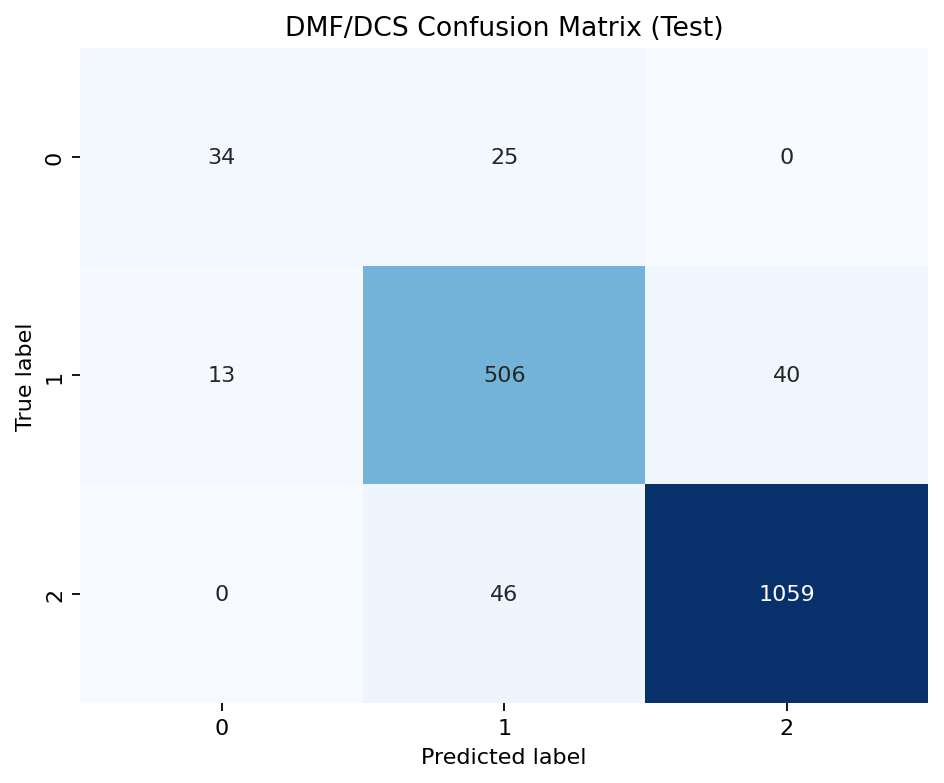

,0,1,2
0,34,25,0
1,13,506,40
2,0,46,1059


Classification report (DMF/DCS test set):
              precision    recall  f1-score   support

           0     0.7234    0.5763    0.6415        59
           1     0.8769    0.9052    0.8908       559
           2     0.9636    0.9584    0.9610      1105

    accuracy                         0.9280      1723
   macro avg     0.8547    0.8133    0.8311      1723
weighted avg     0.9273    0.9280    0.9273      1723

Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm/dmf_dcs_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm/dmf_dcs_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_tlstm/dmf_dcs_test_classification_report.csv


In [11]:
cm = confusion_matrix(y_test, dmf_pred, labels=class_ids)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('DMF/DCS Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (DMF/DCS test set):')
print(classification_report(
    y_test,
    dmf_pred,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        dmf_pred,
        labels=class_ids,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).transpose()
cm_csv_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_confusion_matrix.csv'
cls_csv_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')
print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)


In [12]:
# Inspect disagreement cases where DCS actually selected between TLSTM and GAT.
disagreements = out[out['dcs_case'].eq('disagreement')].copy()
if len(disagreements):
    preview_cols = [
        'row_id', 'ticker', 'rating_date', 'true_label_name',
        'tlstm_pred_label_name', 'gat_pred_label_name', 'dmf_pred_label_name',
        'selected_model', 'tlstm_score', 'gat_score',
    ]
    display(disagreements[preview_cols].head(20))
else:
    print('Khong co case bat dong giua TLSTM va GAT tren test set.')


,row_id,ticker,rating_date,true_label_name,tlstm_pred_label_name,gat_pred_label_name,dmf_pred_label_name,selected_model,tlstm_score,gat_score
12,8182,ABG,2012-08-21,1,1,0,1,tlstm,1.688701,1.247436
15,7086,ABG,2015-03-06,2,2,1,1,gat,1.484604,1.927643
37,6894,AEE,2015-11-20,2,2,1,2,tlstm,1.884508,1.872764
43,8094,ALB,2015-05-29,2,2,1,2,tlstm,1.844152,1.830447
93,7492,APA,2015-01-16,2,2,1,2,tlstm,1.421914,1.403718
96,7235,APA,2016-02-25,2,2,1,1,gat,1.452860,1.601830
168,8522,BCC,2012-06-15,0,1,0,1,tlstm,1.519792,1.178256
203,7285,BSX,2015-11-04,1,1,2,2,gat,1.719943,1.958611
207,8330,BTU,2014-02-20,1,1,0,0,gat,1.383454,1.412840
250,8125,CASA,2016-11-30,1,2,1,1,gat,1.726797,1.780029
